# Replication: Kahiu et al. (2024)
## *Leveraging browse and grazing forage estimates to optimize index-based livestock insurance*
**Scientific Reports** | https://doi.org/10.1038/s41598-024-62893-4

### Models
1. **NDVI** — MODIS MOD09A1/MYD09A1, 8-day 500 m surface reflectance, Planetary Computer. NDVI = (NIR−Red)/(NIR+Red) with QA masking; pixel-wise maximum across Terra/Aqua when dates coincide.
2. **LAIA** — MODIS aggregate LAI, 8-day 500 m (ORNL stack), quality filter + smoothing.

### Methods (paper)
- **Spatial unit:** household-level. EO variables averaged over a **20 km buffer** (communal grazing range).
- **Seasons:** LRLD = March–September; SRSD = October–February (SRSD year = calendar year of the Jan–Feb portion).
- **Outcome:** drought + disease livestock losses in **TLU**, summed over the full season (paper treats them as coupled under forage/water stress).
- **Z-scores:** per **(household, season)** across all reference years **2003–2021** pooled — each year measured against the same long-term baseline.
- **Static covariates:** human landscapes + seasonal water from **2019 Copernicus LC100 / CGLS** (single baseline, not time-matched to survey years, per the paper's Methods).
- **RF:** 500 trees, **50 random seeds** averaged; in-sample RMSE and R² reported.

### Run order
**Fresh run:** 1 → 2 → 3 → 4 → 5 → 6 → 7 → 8 → 8b → 8c → 9 → 10 → 11 → 12 → 13 → 14 → 15 → 16  
**After kernel restart:** RELOAD → 8 (fetch) → 8b → continue as needed

### Data required
- `LAI_Africa_2325_1-20260322_211140/` — ORNL MODIS aggregate LAI `.nc` files
- `IBLIData_CSV_PublicZipped/` — ILRI survey CSVs
- `outputs/` — created automatically
- **Google Earth Engine** (Cell 11): one-time `earthengine authenticate`; set `EE_PROJECT_ID` env var if required


---
## CELL 1 — Install packages

In [1]:
import sys
!{sys.executable} -m pip install -q \
    numpy pandas geopandas xarray netcdf4 h5netcdf \
    rasterio rasterstats shapely pyproj scikit-learn scipy matplotlib \
    requests tqdm joblib rioxarray pystac-client planetary-computer \
    earthengine-api odc-stac
print('Done. Restart kernel if first run.')



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip
Done. Restart kernel if first run.


---
## CELL 2 — Imports and configuration

In [2]:
import os, warnings, datetime, pickle
import numpy as np
import pandas as pd
import geopandas as gpd
import xarray as xr
import rioxarray
import odc.stac
from scipy.fft import dctn, idctn
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy import stats as scipy_stats
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from joblib import Parallel, delayed
from tqdm import tqdm
from rasterstats import zonal_stats as rzonal
from rasterio.transform import from_bounds
import pystac_client
import planetary_computer
warnings.filterwarnings('ignore')

# ── Paths ──────────────────────────────────────────────────────────────
ORNL_DIR  = 'LAI_Africa_2325_1-20260322_211140/'
ILRI_DIR  = 'IBLIData_CSV_PublicZipped/'
ENV_DIR   = 'env_data/'
OUT_DIR   = 'outputs/'
for d in [ENV_DIR, OUT_DIR]:
    os.makedirs(d, exist_ok=True)

# ── Constants ──────────────────────────────────────────────────────────
BUFFER_M      = 20_000
WGS84         = 'EPSG:4326'
REF_YEARS     = list(range(2003, 2022))
SURVEY_ROUNDS = [2009, 2010, 2011, 2012, 2013, 2015, 2021]
LRLD_MONTHS   = list(range(3, 10))
SRSD_MONTHS   = [10, 11, 12, 1, 2]

# ── ILRI column names ──────────────────────────────────────────────────
HHID_COL    = 'hhid'
LAT_COL     = 'gps_latitude'
LON_COL     = 'gps_longitude'
COL_HHID    = 'hhid'
COL_YEAR    = 's6q20a'
COL_MONTH   = 's6q20b'
COL_SPECIES = 's6q21'
COL_REASON  = 's6q22'
COL_NUMLOST = 's6q24'

# ── Z-score: per (household, season) across all reference years ────────
def compute_zscores(df, value_cols, group_cols=('hhid', 'season')):
    df = df.copy()
    for col in value_cols:
        stats = df.groupby(list(group_cols))[col].agg(mu='mean', sigma='std').reset_index()
        df    = df.merge(stats, on=list(group_cols), how='left')
        zcol  = 'z' + col.replace('cum_', '').replace('_mean', '')
        df[zcol] = (df[col] - df['mu']) / df['sigma']
        df    = df.drop(columns=['mu', 'sigma'])
    return df

def get_season(month, year):
    if month in LRLD_MONTHS:  return 'LRLD', year
    elif month in [10,11,12]: return 'SRSD', year + 1
    elif month in [1, 2]:     return 'SRSD', year
    return None, None

# ── Mortality helpers (used in Cell 9 and RELOAD) ─────────────────────
def classify_reason(r):
    r = str(r).lower().strip()
    if any(k in r for k in ['starvation','drought','rain','thirst']): return 'drought'
    elif any(k in r for k in ['disease','sick','illness']): return 'disease'
    elif any(k in r for k in ['raid','rustl','conflict','theft']): return 'conflict'
    elif any(k in r for k in ['predat','lion','leopard','hyena']): return 'predation'
    return 'other'

def get_tlu(s):
    s = str(s).lower()
    if any(k in s for k in ['cattle','cow','bull','ox','bovine']): return 1.0
    if 'camel' in s: return 1.3
    if 'sheep' in s or 'goat' in s: return 0.1
    return np.nan

def get_species_group(s):
    s = str(s).lower()
    if any(k in s for k in ['cattle','cow','bull','ox','bovine']): return 'cattle'
    if 'camel' in s: return 'camel'
    if 'sheep' in s or 'goat' in s: return 'shoat'
    return 'other'

def assign_mort_season(month, year):
    if pd.isna(month) or pd.isna(year): return pd.NA, pd.NA
    m, y = int(month), int(year)
    if m in LRLD_MONTHS:  return 'LRLD', y
    elif m in [10,11,12]: return 'SRSD', y + 1
    elif m in [1, 2]:     return 'SRSD', y
    return pd.NA, pd.NA

print('Configuration ready.')
print(f'ORNL files: {len([f for f in os.listdir(ORNL_DIR) if f.endswith(".nc")])} found')


Configuration ready.
ORNL files: 874 found


---
## CELL 3 — Filename parser and smoothn

In [3]:
def parse_nc_filename(fname):
    date_part = fname.split('.')[1]
    year  = int(date_part[1:5])
    doy   = int(date_part[5:8])
    month = (datetime.date(year, 1, 1) + datetime.timedelta(doy - 1)).month
    return year, doy, month

def smoothn_1d(y, robust=True, max_iter=100, tol=1e-3):
    y    = np.array(y, dtype=float)
    n    = len(y)
    nans = np.isnan(y)
    if nans.all(): return y
    xp = np.where(~nans)[0]
    yf = np.interp(np.arange(n), xp, y[~nans])
    k      = np.arange(1, n + 1)
    Lambda = -2 + 2 * np.cos((k - 1) * np.pi / n)
    s      = 10.0
    W      = np.ones(n); W[nans] = 0
    z      = yf.copy()
    for _ in range(max_iter):
        z_prev = z.copy()
        r      = W * (yf - z)
        gamma  = 1.0 / (1.0 + s * Lambda ** 2)
        dct_z  = dctn(z.reshape(1, -1), norm='ortho').flatten()
        dct_r  = dctn(r.reshape(1, -1), norm='ortho').flatten()
        z      = idctn((gamma * (dct_z + dct_r)).reshape(1, -1), norm='ortho').flatten()
        if robust:
            resid = yf - z
            mad   = np.median(np.abs(resid[~nans])) + 1e-10
            u     = resid / (4.685 * mad)
            W_new = (np.abs(u) < 1) * (1 - u ** 2) ** 2
            W_new[nans] = 0
            W = W_new
        if np.max(np.abs(z - z_prev)) < tol: break
    return z

print('Helper functions defined.')


Helper functions defined.


---
## CELL 4 — Load household locations, buffers, pixel indices
**Saves checkpoint. On kernel restart skip to RELOAD CELL.**

Households after GPS cleaning: 1056
BBOX: (np.float64(35.2), np.float64(1.4), np.float64(38.8), np.float64(4.4))
Buffer area: 1255 km²  (expected ~1257)
LAI pixels in bbox: 621224
Computing pixel-buffer assignments...


Assigning pixels: 100%|██████████| 1056/1056 [00:04<00:00, 232.83it/s]


Households with ≥1 pixel: 1056/1056
Avg pixels per buffer:    5841
Checkpoint saved.


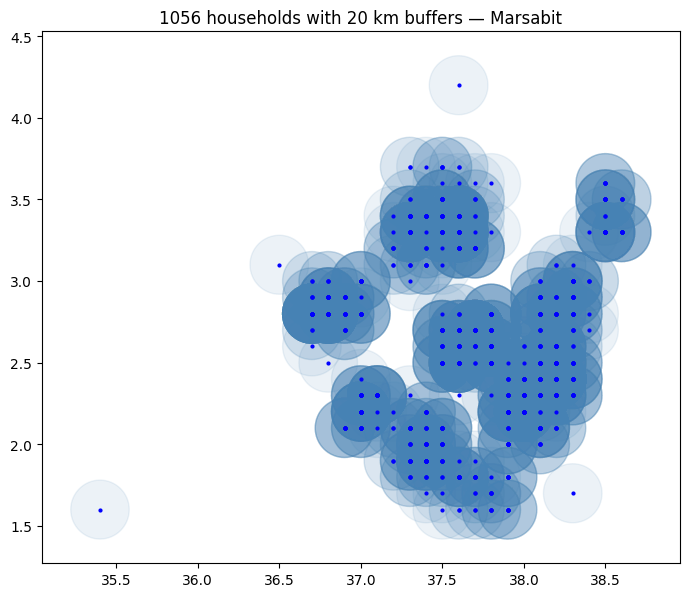

In [4]:
UTM_CRS = 'EPSG:32637'  # local — used only for 20 km buffer construction
hh_loc   = pd.read_csv(os.path.join(ILRI_DIR, 'HH_location_shifted.csv'))
hh_clean = (
    hh_loc[[HHID_COL, LAT_COL, LON_COL]]
    .dropna().drop_duplicates(subset=HHID_COL).reset_index(drop=True)
)
hh_clean = hh_clean[hh_clean[LON_COL] > 35.0].reset_index(drop=True)
print(f'Households after GPS cleaning: {len(hh_clean)}')

BBOX = (
    round(hh_clean[LON_COL].min() - 0.2, 2),
    round(hh_clean[LAT_COL].min() - 0.2, 2),
    round(hh_clean[LON_COL].max() + 0.2, 2),
    round(hh_clean[LAT_COL].max() + 0.2, 2),
)
print(f'BBOX: {BBOX}')

hh_gdf             = gpd.GeoDataFrame(
    hh_clean,
    geometry=gpd.points_from_xy(hh_clean[LON_COL], hh_clean[LAT_COL]),
    crs=WGS84
)
hh_utm             = hh_gdf.to_crs(UTM_CRS)
hh_utm['geometry'] = hh_utm.geometry.buffer(BUFFER_M)
hh_buffers         = hh_utm.to_crs(WGS84)
print(f'Buffer area: {hh_utm.geometry.area.mean()/1e6:.0f} km²  (expected ~1257)')

ds0   = xr.open_dataset(os.path.join(ORNL_DIR, sorted(os.listdir(ORNL_DIR))[0]), engine='netcdf4')
LAT2D = ds0['latitude'].values
LON2D = ds0['longitude'].values
ds0.close()

lon_min, lat_min, lon_max, lat_max = BBOX
BBOX_MASK            = ((LAT2D >= lat_min) & (LAT2D <= lat_max) &
                        (LON2D >= lon_min) & (LON2D <= lon_max))
MARS_ROWS, MARS_COLS = np.where(BBOX_MASK)
MARS_LATS            = LAT2D[MARS_ROWS, MARS_COLS]
MARS_LONS            = LON2D[MARS_ROWS, MARS_COLS]
print(f'LAI pixels in bbox: {BBOX_MASK.sum()}')

print('Computing pixel-buffer assignments...')
hh_lats      = hh_gdf.geometry.y.values
hh_lons      = hh_gdf.geometry.x.values
mean_lat_rad = np.radians(hh_lats.mean())

hh_pixel_idx = []
for i in tqdm(range(len(hh_lats)), desc='Assigning pixels'):
    dlat    = MARS_LATS - hh_lats[i]
    dlon    = MARS_LONS - hh_lons[i]
    dist_km = np.sqrt((dlat*111.32)**2 + (dlon*111.32*np.cos(mean_lat_rad))**2)
    hh_pixel_idx.append(np.where(dist_km <= 20.0)[0])

NCOLS       = 2400
hh_flat_idx = [
    MARS_ROWS[idx]*NCOLS + MARS_COLS[idx] if len(idx)>0 else np.array([])
    for idx in hh_pixel_idx
]
print(f'Households with ≥1 pixel: {sum(len(i)>0 for i in hh_pixel_idx)}/{len(hh_buffers)}')
print(f'Avg pixels per buffer:    {np.mean([len(i) for i in hh_pixel_idx if len(i)>0]):.0f}')

checkpoint = {
    'hh_buffers':hh_buffers, 'hh_gdf':hh_gdf,
    'hh_pixel_idx':hh_pixel_idx, 'hh_flat_idx':hh_flat_idx,
    'MARS_ROWS':MARS_ROWS, 'MARS_COLS':MARS_COLS,
    'MARS_LATS':MARS_LATS, 'MARS_LONS':MARS_LONS,
    'LAT2D':LAT2D, 'LON2D':LON2D,
    'BBOX':BBOX, 'HHID_COL':HHID_COL,
}
with open(f'{OUT_DIR}checkpoint_cell4.pkl', 'wb') as f:
    pickle.dump(checkpoint, f)
print('Checkpoint saved.')

fig, ax = plt.subplots(figsize=(7,8))
hh_buffers.plot(ax=ax, alpha=0.1, edgecolor='steelblue', facecolor='steelblue')
hh_gdf.plot(ax=ax, color='blue', markersize=4, zorder=3)
ax.set_title(f'{len(hh_gdf)} households with 20 km buffers — Marsabit')
plt.tight_layout(); plt.savefig(f'{OUT_DIR}01_buffers.png', dpi=150); plt.show()

---
## RELOAD CELL — Run after kernel restart instead of Cells 1–4

In [5]:
import os, warnings, datetime, pickle
import numpy as np
import pandas as pd
import geopandas as gpd
import xarray as xr
import rioxarray
import odc.stac
from scipy.fft import dctn, idctn
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy import stats as scipy_stats
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from joblib import Parallel, delayed
from tqdm import tqdm
from rasterstats import zonal_stats as rzonal
from rasterio.transform import from_bounds
import pystac_client, planetary_computer
warnings.filterwarnings('ignore')

ORNL_DIR='LAI_Africa_2325_1-20260322_211140/'; ILRI_DIR='IBLIData_CSV_PublicZipped/'
ENV_DIR='env_data/'; OUT_DIR='outputs/'
BUFFER_M=20_000; WGS84='EPSG:4326'
REF_YEARS=list(range(2003,2022)); SURVEY_ROUNDS=[2009,2010,2011,2012,2013,2015,2021]
LRLD_MONTHS=list(range(3,10)); SRSD_MONTHS=[10,11,12,1,2]
HHID_COL='hhid'; LAT_COL='gps_latitude'; LON_COL='gps_longitude'
COL_HHID='hhid'; COL_YEAR='s6q20a'; COL_MONTH='s6q20b'
COL_SPECIES='s6q21'; COL_REASON='s6q22'; COL_NUMLOST='s6q24'

def compute_zscores(df, value_cols, group_cols=('hhid', 'season')):
    df = df.copy()
    for col in value_cols:
        stats = df.groupby(list(group_cols))[col].agg(mu='mean', sigma='std').reset_index()
        df    = df.merge(stats, on=list(group_cols), how='left')
        zcol  = 'z' + col.replace('cum_', '').replace('_mean', '')
        df[zcol] = (df[col] - df['mu']) / df['sigma']
        df    = df.drop(columns=['mu', 'sigma'])
    return df

def get_season(month, year):
    if month in LRLD_MONTHS: return 'LRLD', year
    elif month in [10,11,12]: return 'SRSD', year + 1
    elif month in [1,2]: return 'SRSD', year
    return None, None

def parse_nc_filename(fname):
    d=fname.split('.')[1]; yr=int(d[1:5]); dy=int(d[5:8])
    return yr, dy, (datetime.date(yr,1,1)+datetime.timedelta(dy-1)).month

def smoothn_1d(y, robust=True, max_iter=100, tol=1e-3):
    y=np.array(y,dtype=float); n=len(y); nans=np.isnan(y)
    if nans.all(): return y
    yf=np.interp(np.arange(n),np.where(~nans)[0],y[~nans])
    Lambda=-2+2*np.cos((np.arange(1,n+1)-1)*np.pi/n)
    s=10.0; W=np.ones(n); W[nans]=0; z=yf.copy()
    for _ in range(max_iter):
        zp=z.copy(); r=W*(yf-z); g=1.0/(1.0+s*Lambda**2)
        z=idctn((g*(dctn(z.reshape(1,-1),norm='ortho')+dctn(r.reshape(1,-1),norm='ortho'))).reshape(1,-1),norm='ortho').flatten()
        if robust:
            res=yf-z; mad=np.median(np.abs(res[~nans]))+1e-10
            u=res/(4.685*mad); W_new=(np.abs(u)<1)*(1-u**2)**2; W_new[nans]=0; W=W_new
        if np.max(np.abs(z-zp))<tol: break
    return z

def classify_reason(r):
    r=str(r).lower().strip()
    if any(k in r for k in ['starvation','drought','rain','thirst']): return 'drought'
    elif any(k in r for k in ['disease','sick','illness']): return 'disease'
    elif any(k in r for k in ['raid','rustl','conflict','theft']): return 'conflict'
    elif any(k in r for k in ['predat','lion','leopard','hyena']): return 'predation'
    return 'other'

def get_tlu(s):
    s=str(s).lower()
    if any(k in s for k in ['cattle','cow','bull','ox','bovine']): return 1.0
    if 'camel' in s: return 1.3
    if 'sheep' in s or 'goat' in s: return 0.1
    return np.nan

def get_species_group(s):
    s=str(s).lower()
    if any(k in s for k in ['cattle','cow','bull','ox','bovine']): return 'cattle'
    if 'camel' in s: return 'camel'
    if 'sheep' in s or 'goat' in s: return 'shoat'
    return 'other'

def assign_mort_season(month, year):
    if pd.isna(month) or pd.isna(year): return pd.NA, pd.NA
    m,y=int(month),int(year)
    if m in LRLD_MONTHS: return 'LRLD', y
    elif m in [10,11,12]: return 'SRSD', y+1
    elif m in [1,2]: return 'SRSD', y
    return pd.NA, pd.NA

# ── Restore Cell 4 checkpoint ──────────────────────────────────────────
with open(f'{OUT_DIR}checkpoint_cell4.pkl','rb') as f:
    ck=pickle.load(f)
hh_buffers=ck['hh_buffers']; hh_gdf=ck['hh_gdf']
hh_pixel_idx=ck['hh_pixel_idx']; hh_flat_idx=ck['hh_flat_idx']
MARS_ROWS=ck['MARS_ROWS']; MARS_COLS=ck['MARS_COLS']
MARS_LATS=ck['MARS_LATS']; MARS_LONS=ck['MARS_LONS']
LAT2D=ck['LAT2D']; LON2D=ck['LON2D']
BBOX=ck['BBOX']; HHID_COL=ck['HHID_COL']; NCOLS=2400
print(f'Cell 4 restored: {len(hh_buffers)} households  BBOX={BBOX}')

# ── Restore parquet checkpoints ────────────────────────────────────────
for name, path in [
    ('raw_ts',  f'{OUT_DIR}raw_lai_timeseries.parquet'),
    ('lai_z',   f'{OUT_DIR}lai_zscores.parquet'),
    ('ndvi_z',  f'{OUT_DIR}ndvi_zscores.parquet'),
    ('temp_df', f'{OUT_DIR}temperature_zscores.parquet'),
]:
    if os.path.exists(path):
        globals()[name] = pd.read_parquet(path)
        print(f'{name}: {globals()[name].shape}')
    else:
        print(f'{name}: not found — run the relevant cell to generate it')

ep = f'{OUT_DIR}env_static.csv'
if os.path.exists(ep):
    env_static = pd.read_csv(ep); print(f'env_static: {env_static.shape}')
else:
    print('env_static: not found — run Cell 11')

# ── Rebuild mortality2 ─────────────────────────────────────────────────
losses = pd.read_csv(os.path.join(ILRI_DIR,'S6C Livestock Losses.csv'),encoding='latin-1',low_memory=False)
losses['loss_cat']    = losses[COL_REASON].apply(classify_reason)
losses['tlu_rate']    = losses[COL_SPECIES].apply(get_tlu)
losses['species_grp'] = losses[COL_SPECIES].apply(get_species_group)
losses['n_lost']      = pd.to_numeric(losses[COL_NUMLOST],errors='coerce')
losses['n_lost']      = losses['n_lost'].where(losses['n_lost']>=0)
losses['tlu_lost']    = losses['n_lost']*losses['tlu_rate']
lf = losses[
    losses['loss_cat'].isin(['drought','disease']) &
    losses['tlu_rate'].notna() &
    losses['species_grp'].ne('other') &
    losses['tlu_lost'].notna() &
    (losses['tlu_lost']>0)
].copy()
lf['month_n'] = pd.to_numeric(lf[COL_MONTH],errors='coerce').astype('Int64')
lf['year_n']  = pd.to_numeric(lf[COL_YEAR], errors='coerce').astype('Int64')
lf[['season','season_year']] = lf.apply(
    lambda r: pd.Series(assign_mort_season(r['month_n'],r['year_n'])), axis=1)
lf = lf.dropna(subset=['season','season_year'])
lf = lf[lf['season_year'].isin(SURVEY_ROUNDS)]
mortality2 = (
    lf.groupby([COL_HHID,'season_year','season'])
    .apply(lambda g: pd.Series({
        'mortality_total':  g['tlu_lost'].sum(),
        'mortality_cattle': g.loc[g['species_grp']=='cattle','tlu_lost'].sum(),
        'mortality_camel':  g.loc[g['species_grp']=='camel', 'tlu_lost'].sum(),
        'mortality_shoat':  g.loc[g['species_grp']=='shoat', 'tlu_lost'].sum(),
    }))
    .reset_index().rename(columns={COL_HHID:'hhid','season_year':'survey_year'})
)
print(f'mortality2: {mortality2.shape}')
print('All variables restored.')


Cell 4 restored: 1056 households  BBOX=(np.float64(35.2), np.float64(1.4), np.float64(38.8), np.float64(4.4))
raw_ts: (922944, 5)
lai_z: (41184, 5)
ndvi_z: (41184, 5)
temp_df: (40128, 5)
env_static: (1056, 3)
mortality2: (5931, 7)
All variables restored.


---
## CELL 5 — Extract LAIA from ORNL files
Only the `aggregate` LAI variable is extracted. LAIW/LAIH (partitioned) are not used.


In [6]:
def extract_laia_all_households(fpath, hh_flat_idx):
    ds   = xr.open_dataset(fpath, engine='netcdf4')
    aggr = ds['aggregate'].values.astype(np.float32).ravel()
    ds.close()
    aggr[aggr > 70] = np.nan
    n_hh  = len(hh_flat_idx)
    a_out = np.full(n_hh, np.nan, dtype=np.float32)
    for i, flat in enumerate(hh_flat_idx):
        if len(flat) == 0: continue
        a_out[i] = np.nanmean(aggr[flat])
    return a_out

def process_one_file(fname):
    fpath = os.path.join(ORNL_DIR, fname)
    year, doy, month = parse_nc_filename(fname)
    a = extract_laia_all_households(fpath, hh_flat_idx)
    return year, doy, month, a

all_files = sorted([f for f in os.listdir(ORNL_DIR) if f.endswith('.nc')])
hhids = hh_buffers[HHID_COL].values; n_hh = len(hhids)
print(f'Extracting {len(all_files)} files × {n_hh} households (LAIA only)...')

results = Parallel(n_jobs=-1, verbose=0)(
    delayed(process_one_file)(fname)
    for fname in tqdm(all_files, desc='Extracting LAIA')
)

n_total   = len(results) * n_hh
year_arr  = np.empty(n_total, dtype=np.int16)
doy_arr   = np.empty(n_total, dtype=np.int16)
mon_arr   = np.empty(n_total, dtype=np.int8)
hhid_arr  = np.empty(n_total, dtype=object)
laia_arr  = np.empty(n_total, dtype=np.float32)

for f_idx, (year, doy, month, a) in enumerate(results):
    s, e = f_idx * n_hh, (f_idx + 1) * n_hh
    year_arr[s:e] = year; doy_arr[s:e] = doy; mon_arr[s:e] = month
    hhid_arr[s:e] = hhids; laia_arr[s:e] = a

raw_ts = pd.DataFrame({
    'hhid': hhid_arr, 'year': year_arr,
    'doy':  doy_arr,  'month': mon_arr,
    'LAIA': laia_arr,
})
print(f'Done. Shape: {raw_ts.shape}')
raw_ts.to_parquet(f'{OUT_DIR}raw_lai_timeseries.parquet', index=False)
print('Saved → outputs/raw_lai_timeseries.parquet')


Extracting 874 files × 1056 households (LAIA only)...


Extracting LAIA: 100%|██████████| 874/874 [01:26<00:00, 10.14it/s]


Done. Shape: (922944, 5)
Saved → outputs/raw_lai_timeseries.parquet


---
## CELL 6 — Smooth LAIA, assign seasons, seasonal cumulative
*(Dryad LAIH/LAIW reconstruction removed — LAIp not used in this analysis.)*


In [7]:
# raw_ts = pd.read_parquet(f'{OUT_DIR}raw_lai_timeseries.parquet')  # reload if needed

def smooth_one_household(hhid, grp):
    g = grp.sort_values(['year', 'doy']).copy()
    g['LAIA_s'] = smoothn_1d(g['LAIA'].values, robust=True)
    return g

print('Applying smoothn per household (parallel)...')
smoothed = Parallel(n_jobs=-1, verbose=0)(
    delayed(smooth_one_household)(hhid, grp)
    for hhid, grp in tqdm(raw_ts.groupby('hhid'), desc='Smoothing')
)
smooth_ts = pd.concat(smoothed, ignore_index=True)

smooth_ts[['season', 'season_year']] = smooth_ts.apply(
    lambda r: pd.Series(get_season(r['month'], r['year'])), axis=1
)
smooth_ts = smooth_ts.dropna(subset=['season'])

seasonal_cum = (
    smooth_ts.groupby(['hhid', 'season_year', 'season'])
    [['LAIA_s']]
    .sum().reset_index()
    .rename(columns={'LAIA_s': 'cum_LAIA'})
)

print(f'Seasonal records: {len(seasonal_cum)}')
print(f'cum_LAIA mean: {seasonal_cum["cum_LAIA"].mean():.3f}')

seasonal_cum.to_parquet(f'{OUT_DIR}seasonal_cum_lai.parquet', index=False)
print('Saved.')


Applying smoothn per household (parallel)...


Smoothing: 100%|██████████| 1056/1056 [00:00<00:00, 1115.73it/s]


Seasonal records: 41184
cum_LAIA mean: 110.206
Saved.


---
## CELL 7 — Z-score standardization for LAIA
Z-scores are computed **per (household, season)** across all reference years 2003–2021.
This gives each year's value relative to that location's long-term seasonal baseline.


LAIA Z-score summary:
  zLAIA: mean=0.0000  std=0.9740
  NaN rate: 0.0%

2009 LRLD drought check:
  zLAIA mean: -1.140  (expected: negative)


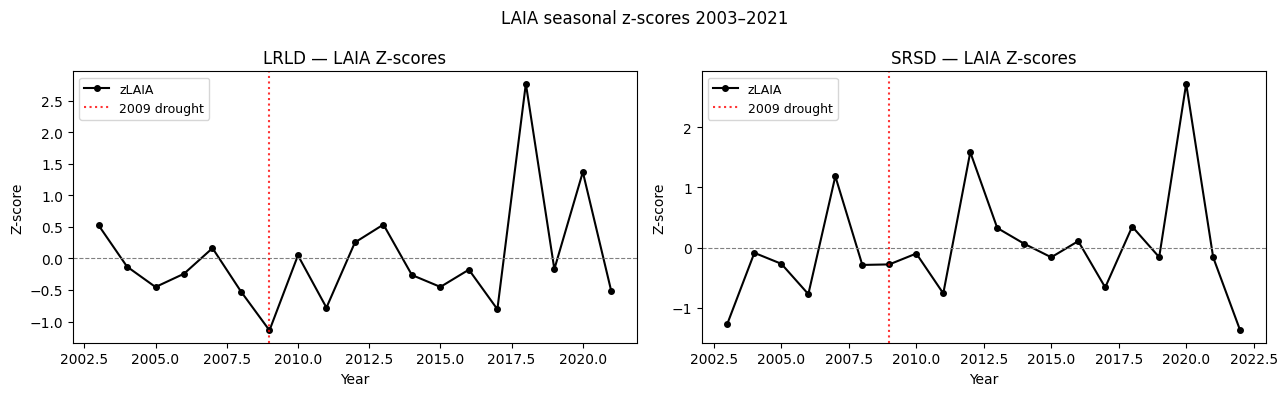

Saved.


In [8]:
# seasonal_cum = pd.read_parquet(f'{OUT_DIR}seasonal_cum_lai.parquet')  # reload if needed

# compute_zscores groups by ('hhid','season') — mean/std computed across all years
lai_z = compute_zscores(seasonal_cum, ['cum_LAIA'], group_cols=('hhid', 'season'))

print('LAIA Z-score summary:')
print(f'  zLAIA: mean={lai_z["zLAIA"].mean():.4f}  std={lai_z["zLAIA"].std():.4f}')
print(f'  NaN rate: {lai_z["zLAIA"].isna().mean():.1%}')

d09 = lai_z[(lai_z['season_year']==2009) & (lai_z['season']=='LRLD')]
print(f'\n2009 LRLD drought check:')
print(f'  zLAIA mean: {d09["zLAIA"].mean():.3f}  (expected: negative)')

lai_z.to_parquet(f'{OUT_DIR}lai_zscores.parquet', index=False)

ts = lai_z.groupby(['season_year','season'])[['zLAIA']].mean().reset_index()
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, s in zip(axes, ['LRLD', 'SRSD']):
    sub = ts[ts['season'] == s]
    ax.plot(sub['season_year'], sub['zLAIA'], 'k-o', ms=4, lw=1.5, label='zLAIA')
    ax.axhline(0, color='grey', lw=0.8, ls='--')
    ax.axvline(2009, color='red', lw=1.5, ls=':', alpha=0.8, label='2009 drought')
    ax.set_title(f'{s} — LAIA Z-scores')
    ax.set_xlabel('Year'); ax.set_ylabel('Z-score'); ax.legend(fontsize=9)
plt.suptitle('LAIA seasonal z-scores 2003–2021', fontsize=12)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}02_fig7_lai_timeseries.png', dpi=150)
plt.show()
print('Saved.')


---
## CELL 8 — Fetch MOD09A1/MYD09A1 items from Planetary Computer

MODIS `modis-09A1-061` provides **8-day 500 m** Red/NIR surface reflectance (Terra MOD09A1 and Aqua MYD09A1). NDVI = (NIR−Red)/(NIR+Red) with MODLAND QA masking. When Terra and Aqua share a composite date, the pixel-wise maximum valid NDVI is kept — analogous to the paper's dual-sensor compositing.

Processing matches LAIA: buffer mean → per-household `smoothn_1d` → LRLD/SRSD seasons → cumulative NDVI → z-score per `(hhid, season)` over 2003–2021.

Set `MOD09_INCLUDE_MYD = False` to use Terra only (~half the items, faster for development).


In [9]:
# ── Fetch MOD09A1 / MYD09A1 (8-day 500 m) from Planetary Computer ─────────
if 'hh_buffers' not in globals():
    raise RuntimeError('Run CELL 4 or RELOAD first (hh_buffers missing).')

# Tighter bbox than global BBOX (ORNL/LAI) shrinks each mosaic read.
# Paper uses Terra + Aqua; set MOD09_INCLUDE_MYD = False to load ~half the STAC items (faster dev).
MOD09_INCLUDE_MYD = True

_m = 0.035  # degrees margin outside union of household 20km buffers (~4 km)
_minx, _miny, _maxx, _maxy = hh_buffers.total_bounds
NDVI_BBOX = (_minx - _m, _miny - _m, _maxx + _m, _maxy + _m)
lon_min, lat_min, lon_max, lat_max = NDVI_BBOX
REFL_SCALE = 0.0001

print('Opening Planetary Computer STAC catalog…', flush=True)
catalog = pystac_client.Client.open(
    'https://planetarycomputer.microsoft.com/api/stac/v1',
    modifier=planetary_computer.sign_inplace,
)

search_sr = catalog.search(
    collections=['modis-09A1-061'],
    bbox=[lon_min, lat_min, lon_max, lat_max],
    datetime=f'{REF_YEARS[0]}-01-01/{REF_YEARS[-1]}-12-31',
)
items_sr = list(search_sr.get_items())
if not MOD09_INCLUDE_MYD:
    items_sr = [it for it in items_sr if it.id.startswith('MOD09A1')]
print(f'Found {len(items_sr)} MOD09 items (NDVI_BBOX, Aqua={"on" if MOD09_INCLUDE_MYD else "off"})', flush=True)
if items_sr:
    print('Sample id:', items_sr[0].id, flush=True)


Opening Planetary Computer STAC catalog…
Found 1750 MOD09 items (NDVI_BBOX, Aqua=on)
Sample id: MYD09A1.A2021361.h21v08.061.2022005045025


---
## CELL 8b — Load NDVI cube and extract per-household means


In [10]:
import rasterio
from rasterio.enums import Resampling
from rasterio.vrt import WarpedVRT
from rasterio.features import geometry_mask
from rasterio.transform import from_bounds as _from_bounds
from shapely.geometry import mapping as _mapping
from collections import defaultdict
import pyproj

if 'NDVI_BBOX' not in globals() or 'items_sr' not in globals():
    raise RuntimeError('Run Cell 8 fetch first (defines NDVI_BBOX and items_sr).')

lon_min, lat_min, lon_max, lat_max = NDVI_BBOX

# ── Target grid: WGS84, ~500 m pixel size ─────────────────────────────
# Work in WGS84 throughout so household buffers need no reprojection.
# 500 m ≈ 0.0045 deg at equator; use 0.005 deg (≈550 m) for a clean grid.
OUT_CRS   = 'EPSG:4326'
OUT_RES   = 0.005          # degrees per pixel
OUT_WIDTH  = max(1, int(round((lon_max - lon_min) / OUT_RES)))
OUT_HEIGHT = max(1, int(round((lat_max - lat_min) / OUT_RES)))
OUT_TRANSFORM = _from_bounds(
    west=lon_min, south=lat_min, east=lon_max, north=lat_max,
    width=OUT_WIDTH, height=OUT_HEIGHT,
)
print(f'Output grid: {OUT_HEIGHT}×{OUT_WIDTH}  ({OUT_RES}° pixels, WGS84)', flush=True)

BAND_KEYS = {
    'b01': ['sur_refl_b01'],
    'b02': ['sur_refl_b02'],
    'qc':  ['sur_refl_qc_500m'],
}


def _get_href(item, band_aliases):
    """Return signed href for the first matching asset key."""
    for alias in band_aliases:
        if alias in item.assets:
            return planetary_computer.sign(item.assets[alias].href)
    for key, asset in item.assets.items():
        if alias in key.lower():
            return planetary_computer.sign(asset.href)
    return None


def _read_band_wgs84(href, retries=4):
    """
    Open a COG href (signed), warp on-the-fly to the output WGS84 grid,
    return float32 array (OUT_HEIGHT, OUT_WIDTH).  NaN for nodata.
    Signs a fresh URL on every retry.
    """
    import time
    for attempt in range(retries):
        try:
            with rasterio.open(href) as src:
                with WarpedVRT(
                    src,
                    crs=OUT_CRS,
                    resampling=Resampling.nearest,
                    transform=OUT_TRANSFORM,
                    width=OUT_WIDTH,
                    height=OUT_HEIGHT,
                ) as vrt:
                    arr = vrt.read(1).astype(np.float32)
                    nd  = vrt.nodata
                    if nd is not None:
                        arr[arr == nd] = np.nan
                    return arr
        except Exception as e:
            if attempt == retries - 1:
                return None           # skip bad tile rather than crashing
            time.sleep(2 ** attempt)  # 1s, 2s, 4s back-off
    return None


def _item_dt(it):
    dt = getattr(it, 'datetime', None)
    if dt is None:
        props = getattr(it, 'properties', None) or {}
        dt = props.get('datetime') or props.get('start_datetime')
    return pd.to_datetime(dt) if dt is not None else None


def _read_one_item(item):
    """
    Read b01, b02, qc for one STAC item; compute QA-masked NDVI.
    Returns (date, ndvi_2d) where ndvi_2d is (OUT_HEIGHT, OUT_WIDTH) float32.
    Signs URLs immediately before each read.
    """
    dt = _item_dt(item)
    if dt is None:
        return None, None

    h_b01 = _get_href(item, BAND_KEYS['b01'])
    h_b02 = _get_href(item, BAND_KEYS['b02'])
    h_qc  = _get_href(item, BAND_KEYS['qc'])
    if not all([h_b01, h_b02, h_qc]):
        return None, None

    b01 = _read_band_wgs84(h_b01)
    b02 = _read_band_wgs84(h_b02)
    qc  = _read_band_wgs84(h_qc)
    if b01 is None or b02 is None or qc is None:
        return None, None

    qa_ok = (qc.astype(np.uint16) & np.uint16(3)) <= np.uint16(1)
    valid = qa_ok & (b01 > -2000) & (b01 < 16000) & (b02 > -2000) & (b02 < 16000)
    red  = np.where(valid, b01 * REFL_SCALE, np.nan)
    nir  = np.where(valid, b02 * REFL_SCALE, np.nan)
    denom = nir + red
    ndvi = np.where(
        np.isfinite(denom) & (np.abs(denom) > 1e-6),
        (nir - red) / denom, np.nan,
    ).astype(np.float32)
    return dt.date(), ndvi


# ── Process all items in parallel ─────────────────────────────────────
# Filter to REF_YEARS
items_in_range = [
    it for it in items_sr
    if (lambda d: d is not None and REF_YEARS[0] <= d.year <= REF_YEARS[-1])(_item_dt(it))
]
print(f'Processing {len(items_in_range)} items (parallel, {OUT_HEIGHT}×{OUT_WIDTH} grid)…', flush=True)

raw_results = Parallel(n_jobs=-1, verbose=0)(
    delayed(_read_one_item)(it)
    for it in tqdm(items_in_range, desc='NDVI items')
)

# Filter failures
raw_results = [(dt, arr) for dt, arr in raw_results if dt is not None]
print(f'Valid items: {len(raw_results)} / {len(items_in_range)}', flush=True)
if not raw_results:
    raise RuntimeError('All items failed — check NDVI_BBOX and asset keys.')

# ── Collapse duplicate dates: pixel-wise max of valid NDVI ────────────
dates   = pd.to_datetime([r[0] for r in raw_results])
arrays  = np.stack([r[1] for r in raw_results], axis=0)   # (N, H, W)
uniq_dates, inv = np.unique(dates, return_inverse=True)
Tu = len(uniq_dates)
N, H, W = arrays.shape

out_cube = np.full((Tu, H, W), np.nan, dtype=np.float32)
filled   = np.where(np.isfinite(arrays), arrays, -np.inf)
for u in range(Tu):
    mask = inv == u
    best = filled[mask].max(axis=0)
    out_cube[u] = np.where(best == -np.inf, np.nan, best)

print(f'NDVI cube: {Tu} × {H} × {W}', flush=True)

# ── Precompute buffer masks (hh_buffers already in WGS84) ─────────────
# OUT_TRANSFORM is north-up (built from lat_min→lat_max south→north),
# but arrays are stored with row 0 = south. Flip for geometry_mask.
print('Buffer masks…', flush=True)
# geometry_mask expects north-up: flip vertically
transform_north_up = _from_bounds(
    west=lon_min, south=lat_min, east=lon_max, north=lat_max,
    width=OUT_WIDTH, height=OUT_HEIGHT,
)
# rasterio from_bounds always returns a north-up transform;
# confirm row direction matches
n_hh    = len(hh_buffers)
hhids_v = hh_buffers[HHID_COL].values
W_mat   = np.zeros((n_hh, H * W), dtype=np.float32)
for i, (_, row) in enumerate(hh_buffers.iterrows()):
    m = ~geometry_mask(
        [_mapping(row.geometry)],
        transform=transform_north_up, invert=False,
        out_shape=(H, W), all_touched=True,
    )
    W_mat[i] = m.ravel().astype(np.float32)
print(f'Masks done — mean pixels/buffer: {W_mat.sum(axis=1).mean():.0f}', flush=True)

# ── Flip cube to north-up so rows match geometry_mask layout ──────────
# from_bounds produces a north-up transform (origin at top-left = NW corner).
# Our cube rows go south→north (row 0 = southernmost); flip to match.
cube_nu = out_cube[:, ::-1, :]      # north-up: row 0 = northernmost

# ── Matrix multiply for zonal means ───────────────────────────────────
T2, H2, W2 = cube_nu.shape
cube_2d     = cube_nu.reshape(T2, -1).astype(np.float32)
valid_2d    = np.isfinite(cube_2d).astype(np.float32)
filled_2d   = np.where(np.isfinite(cube_2d), cube_2d, 0.0).astype(np.float32)
sum_v       = filled_2d @ W_mat.T
cnt_v       = valid_2d  @ W_mat.T
cnt_v[cnt_v == 0] = np.nan
ndvi_matrix = (sum_v / cnt_v).astype(np.float32)

# ── Long dataframe ─────────────────────────────────────────────────────
ndvi_ts = (
    pd.DataFrame(ndvi_matrix, index=pd.to_datetime(uniq_dates), columns=hhids_v)
    .stack().reset_index()
)
ndvi_ts.columns = ['date', 'hhid', 'NDVI']
ndvi_ts['year']  = ndvi_ts['date'].dt.year
ndvi_ts['doy']   = ndvi_ts['date'].dt.dayofyear
ndvi_ts['month'] = ndvi_ts['date'].dt.month
ndvi_ts = ndvi_ts[ndvi_ts['year'].isin(REF_YEARS)].reset_index(drop=True)

print(
    f'Extracted {len(ndvi_ts):,} rows  '
    f'NDVI {ndvi_ts["NDVI"].min():.3f}–{ndvi_ts["NDVI"].max():.3f}  '
    f'missing {ndvi_ts["NDVI"].isna().mean():.1%}',
    flush=True,
)
ndvi_8day = ndvi_ts   # MOD09 is natively 8-day
ndvi_8day.to_parquet(f'{OUT_DIR}raw_ndvi_timeseries.parquet', index=False)
print('Saved → outputs/raw_ndvi_timeseries.parquet', flush=True)


Output grid: 606×726  (0.005° pixels, WGS84)
Processing 1748 items (parallel, 606×726 grid)…


NDVI items:   1%|          | 20/1748 [00:05<08:19,  3.46it/s]/var/folders/m6/t8891b6n387709tqj500t0z00000gn/T/ipykernel_68843/2781901919.py:113: RuntimeWarning: divide by zero encountered in divide
/var/folders/m6/t8891b6n387709tqj500t0z00000gn/T/ipykernel_68843/2781901919.py:113: RuntimeWarning: divide by zero encountered in divide
/var/folders/m6/t8891b6n387709tqj500t0z00000gn/T/ipykernel_68843/2781901919.py:113: RuntimeWarning: divide by zero encountered in divide
/var/folders/m6/t8891b6n387709tqj500t0z00000gn/T/ipykernel_68843/2781901919.py:113: RuntimeWarning: divide by zero encountered in divide
NDVI items:   2%|▏         | 30/1748 [00:08<08:20,  3.43it/s]/var/folders/m6/t8891b6n387709tqj500t0z00000gn/T/ipykernel_68843/2781901919.py:113: RuntimeWarning: divide by zero encountered in divide
/var/folders/m6/t8891b6n387709tqj500t0z00000gn/T/ipykernel_68843/2781901919.py:113: RuntimeWarning: invalid value encountered in divide
/var/folders/m6/t8891b6n387709tqj500t0z00000gn/T/ipykerne

Valid items: 1748 / 1748
NDVI cube: 874 × 606 × 726
Buffer masks…
Masks done — mean pixels/buffer: 4218
Extracted 922,944 rows  NDVI -0.488–0.816  missing 0.0%
Saved → outputs/raw_ndvi_timeseries.parquet


---
## CELL 8c — Smooth, season-assign, cumulate, z-score NDVI


Smoothing NDVI per household...


NDVI smooth: 100%|██████████| 1056/1056 [00:01<00:00, 1003.74it/s]


Seasonal NDVI records: 41184
cum_NDVI mean: 4.5047

NDVI Z-score summary:
  zNDVI: mean=-0.0000  std=0.9740
  2009 LRLD zNDVI mean: -0.928  (expected: negative)


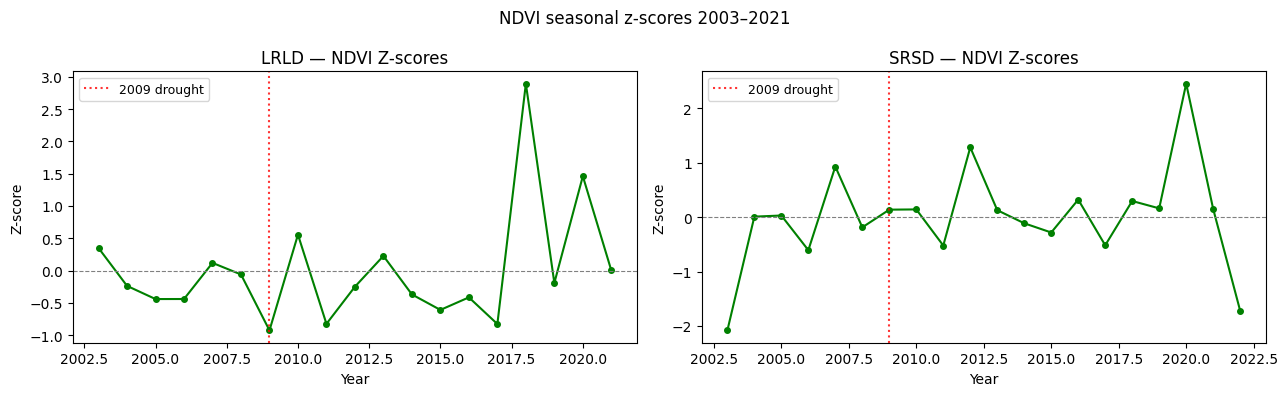

Saved.


In [11]:
# 8-day MOD09-derived NDVI (after household smoothing)
# ndvi_8day = pd.read_parquet(f'{OUT_DIR}raw_ndvi_timeseries.parquet')  # reload if needed

def smooth_ndvi_one_household(hhid, grp):
    g = grp.sort_values(['year', 'doy']).copy()
    g['NDVI_s'] = smoothn_1d(g['NDVI'].values, robust=True)
    return g

print('Smoothing NDVI per household...')
ndvi_smoothed_list = Parallel(n_jobs=-1, verbose=0)(
    delayed(smooth_ndvi_one_household)(hhid, grp)
    for hhid, grp in tqdm(ndvi_8day.groupby('hhid'), desc='NDVI smooth')
)
ndvi_smooth = pd.concat(ndvi_smoothed_list, ignore_index=True)

# Assign seasons (same logic as LAI)
ndvi_smooth[['season', 'season_year']] = ndvi_smooth.apply(
    lambda r: pd.Series(get_season(r['month'], r['year'])), axis=1
)
ndvi_smooth = ndvi_smooth.dropna(subset=['season'])

# Cumulative seasonal NDVI per household
ndvi_cum = (
    ndvi_smooth.groupby(['hhid', 'season_year', 'season'])
    [['NDVI_s']]
    .sum().reset_index()
    .rename(columns={'NDVI_s': 'cum_NDVI'})
)

print(f'Seasonal NDVI records: {len(ndvi_cum)}')
print(f'cum_NDVI mean: {ndvi_cum["cum_NDVI"].mean():.4f}')

# Z-score: per (household, season) across all years — same approach as LAIA
ndvi_z = compute_zscores(ndvi_cum, ['cum_NDVI'], group_cols=('hhid', 'season'))
print('\nNDVI Z-score summary:')
print(f'  zNDVI: mean={ndvi_z["zNDVI"].mean():.4f}  std={ndvi_z["zNDVI"].std():.4f}')

d09 = ndvi_z[(ndvi_z['season_year']==2009) & (ndvi_z['season']=='LRLD')]
print(f'  2009 LRLD zNDVI mean: {d09["zNDVI"].mean():.3f}  (expected: negative)')

ndvi_z.to_parquet(f'{OUT_DIR}ndvi_zscores.parquet', index=False)

# Quick time-series plot
ts = ndvi_z.groupby(['season_year','season'])[['zNDVI']].mean().reset_index()
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, s in zip(axes, ['LRLD', 'SRSD']):
    sub = ts[ts['season'] == s]
    ax.plot(sub['season_year'], sub['zNDVI'], 'g-o', ms=4, lw=1.5)
    ax.axhline(0, color='grey', lw=0.8, ls='--')
    ax.axvline(2009, color='red', lw=1.5, ls=':', alpha=0.8, label='2009 drought')
    ax.set_title(f'{s} — NDVI Z-scores')
    ax.set_xlabel('Year'); ax.set_ylabel('Z-score'); ax.legend(fontsize=9)
plt.suptitle('NDVI seasonal z-scores 2003–2021', fontsize=12)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}02b_fig7_ndvi_timeseries.png', dpi=150)
plt.show()
print('Saved.')


---
## Sanity check — NDVI vs LAIA z-scores
Run this to confirm `zNDVI` and `zLAIA` are distinct before running the RF.

In [12]:
# Quick sanity check: if these are identical something is wrong upstream
_check = lai_z[['hhid','season_year','season','zLAIA']].merge(
    ndvi_z[['hhid','season_year','season','zNDVI']],
    on=['hhid','season_year','season'], how='inner'
)
corr = _check['zLAIA'].corr(_check['zNDVI'])
print(f'Corr(zLAIA, zNDVI) on matched rows: {corr:.4f}')
print(f'zLAIA std: {_check["zLAIA"].std():.4f}   zNDVI std: {_check["zNDVI"].std():.4f}')
print(f'Mean |zLAIA - zNDVI|: {(_check["zLAIA"] - _check["zNDVI"]).abs().mean():.4f}')
if corr > 0.999:
    print('WARNING: indices are numerically identical — check raw_ndvi/lai parquet files')
    print('  Possible cause: ndvi_8day was accidentally overwritten with lai data')
else:
    print(f'OK — indices are correlated but distinct (expected for MODIS vegetation products)')
    print(f'The paper also reports near-identical NDVI vs LAIa performance; this is correct.')
print()
print('Sample zLAIA vs zNDVI (2009 LRLD):')
print(_check[(_check.season_year==2009)&(_check.season=='LRLD')][['hhid','zLAIA','zNDVI']].head(8).to_string(index=False))


Corr(zLAIA, zNDVI) on matched rows: 0.8268
zLAIA std: 0.9740   zNDVI std: 0.9740
Mean |zLAIA - zNDVI|: 0.4329
OK — indices are correlated but distinct (expected for MODIS vegetation products)
The paper also reports near-identical NDVI vs LAIa performance; this is correct.

Sample zLAIA vs zNDVI (2009 LRLD):
 hhid     zLAIA     zNDVI
 1002 -0.935594 -0.706937
 1003 -0.964123 -0.737786
 1004 -0.909068 -0.759241
 1005 -0.964123 -0.737786
 1006 -1.273921 -0.808295
 1007 -0.755006 -0.797375
 1008 -1.523498 -0.859277
 1009 -1.523498 -0.859277


---
## CELL 9 — Process ILRI mortality (S6C drought+disease losses)


In [13]:
# Functions classify_reason, get_tlu, get_species_group, assign_mort_season
# are defined in Cell 2 (config). This cell loads and processes the ILRI data.

losses = pd.read_csv(os.path.join(ILRI_DIR,'S6C Livestock Losses.csv'),
                     encoding='latin-1', low_memory=False)
losses['loss_cat']    = losses[COL_REASON].apply(classify_reason)
losses['tlu_rate']    = losses[COL_SPECIES].apply(get_tlu)
losses['species_grp'] = losses[COL_SPECIES].apply(get_species_group)
losses['n_lost']      = pd.to_numeric(losses[COL_NUMLOST], errors='coerce')
losses['n_lost']      = losses['n_lost'].where(losses['n_lost'] >= 0)
losses['tlu_lost']    = losses['n_lost'] * losses['tlu_rate']

print('Loss category distribution:')
pct = losses['loss_cat'].value_counts(normalize=True)*100
for cat, p in pct.items(): print(f'  {cat:12s}: {p:.1f}%')

lf = losses[
    losses['loss_cat'].isin(['drought','disease']) &
    losses['tlu_rate'].notna() &
    losses['species_grp'].ne('other') &
    losses['tlu_lost'].notna() &
    (losses['tlu_lost'] > 0)
].copy()
lf['month_n'] = pd.to_numeric(lf[COL_MONTH], errors='coerce').astype('Int64')
lf['year_n']  = pd.to_numeric(lf[COL_YEAR],  errors='coerce').astype('Int64')
lf[['season','season_year']] = lf.apply(
    lambda r: pd.Series(assign_mort_season(r['month_n'], r['year_n'])), axis=1)
lf = lf.dropna(subset=['season','season_year'])
lf = lf[lf['season_year'].isin(SURVEY_ROUNDS)]

mortality2 = (
    lf.groupby([COL_HHID,'season_year','season'])
    .apply(lambda g: pd.Series({
        'mortality_total':  g['tlu_lost'].sum(),
        'mortality_cattle': g.loc[g['species_grp']=='cattle','tlu_lost'].sum(),
        'mortality_camel':  g.loc[g['species_grp']=='camel', 'tlu_lost'].sum(),
        'mortality_shoat':  g.loc[g['species_grp']=='shoat', 'tlu_lost'].sum(),
    }))
    .reset_index()
    .rename(columns={COL_HHID:'hhid', 'season_year':'survey_year'})
)
print(f'\nMortality records: {len(mortality2)}')
print(f'  mean={mortality2["mortality_total"].mean():.2f}  std={mortality2["mortality_total"].std():.2f}')


Loss category distribution:
  drought     : 46.6%
  disease     : 33.3%
  predation   : 11.2%
  other       : 7.4%
  conflict    : 1.5%

Mortality records: 5931
  mean=3.42  std=6.60


---
## CELL 10 — TerraClimate temperature via Planetary Computer


In [14]:
print('Opening TerraClimate from Planetary Computer...')
catalog    = pystac_client.Client.open(
    'https://planetarycomputer.microsoft.com/api/stac/v1',
    modifier=planetary_computer.sign_inplace,
)
collection  = catalog.get_collection('terraclimate')
asset       = collection.assets['zarr-abfs']
open_kwargs = asset.extra_fields['xarray:open_kwargs']
open_kwargs.pop('chunks', None)
ds_tc_full  = xr.open_dataset(asset.href, **open_kwargs, chunks='auto')
print(f'Time: {ds_tc_full.time.values[0]} → {ds_tc_full.time.values[-1]}')

tc_lon_min, tc_lat_min, tc_lon_max, tc_lat_max = BBOX
ds_tc = ds_tc_full.sel(
    lon  = slice(tc_lon_min, tc_lon_max),
    lat  = slice(tc_lat_max, tc_lat_min),
    time = slice(f'{REF_YEARS[0]}-01-01', f'{REF_YEARS[-1]}-12-31')
)[['tmax']].load()
print(f'Cropped shape: {ds_tc["tmax"].shape}')

tmax_mean = float(ds_tc['tmax'].mean())
if tmax_mean > 100:
    print('Applying scale 0.1'); ds_tc['tmax'] = ds_tc['tmax'] * 0.1
print(f'tmax range: {float(ds_tc["tmax"].min()):.1f}–{float(ds_tc["tmax"].max()):.1f} °C')

def extract_temp_one_year_season(year, season):
    months  = LRLD_MONTHS if season=='LRLD' else SRSD_MONTHS
    da      = ds_tc['tmax'].sel(
        time=ds_tc.time.dt.year.isin([year]) & ds_tc.time.dt.month.isin(months))
    if len(da.time)==0: return year, season, np.full(len(hh_buffers), np.nan)
    da_mean = da.mean(dim='time')
    arr     = da_mean.values.astype(np.float32)
    tc_lats = ds_tc.lat.values.copy()
    tc_lons = ds_tc.lon.values.copy()
    if tc_lats[0] < tc_lats[-1]:
        arr=np.flipud(arr); tc_lats=tc_lats[::-1]
    transform = from_bounds(
        west=float(tc_lons.min()), south=float(tc_lats.min()),
        east=float(tc_lons.max()), north=float(tc_lats.max()),
        width=arr.shape[1], height=arr.shape[0],
    )
    stats = rzonal(hh_buffers, arr, affine=transform,
                   stats=['mean'], all_touched=True, nodata=-9999)
    return year, season, np.array(
        [s['mean'] if s['mean'] is not None else np.nan for s in stats])

ysc = [(yr,s) for yr in REF_YEARS for s in ['LRLD','SRSD']]
print(f'Extracting temperature ({len(ysc)} combos)...')
temp_results = Parallel(n_jobs=-1, verbose=0)(
    delayed(extract_temp_one_year_season)(yr,s)
    for yr,s in tqdm(ysc, desc='Temperature')
)

n_t=len(ysc)*len(hh_buffers); hhids=hh_buffers[HHID_COL].values
ha=np.empty(n_t,dtype=object); ya=np.empty(n_t,dtype=np.int16)
sa=np.empty(n_t,dtype=object); ta=np.empty(n_t,dtype=np.float32)
for idx,(year,season,vals) in enumerate(temp_results):
    s,e=idx*len(hh_buffers),(idx+1)*len(hh_buffers)
    ha[s:e]=hhids; ya[s:e]=year; sa[s:e]=season; ta[s:e]=vals

temp_df = pd.DataFrame({'hhid':ha,'year':ya,'season':sa,'temp_mean':ta})
# Z-score: per (household, season) across all years
temp_df = compute_zscores(temp_df, ['temp_mean'], group_cols=('hhid','season'))
temp_df = temp_df.rename(columns={'ztemp':'zTemp'})
print(f'Records: {len(temp_df)}  Missing: {temp_df["zTemp"].isna().mean():.1%}')
temp_df.to_parquet(f'{OUT_DIR}temperature_zscores.parquet', index=False)
print('Saved.')


Opening TerraClimate from Planetary Computer...
Time: 1958-01-01T00:00:00.000000000 → 2021-12-01T00:00:00.000000000
Cropped shape: (228, 72, 86)
tmax range: 19.4–44.0 °C
Extracting temperature (38 combos)...


Temperature: 100%|██████████| 38/38 [00:01<00:00, 32.03it/s]


Records: 40128  Missing: 0.0%
Saved.


---
## CELL 11 — Static covariates: Copernicus LC100 + seasonal water (2019)

Paper (Kahiu et al.): human encroachment = **Copernicus Global Land Service LC100
Collection 3, year 2019** (100 m), fractional built-up + cultivated summed within
the 20 km household buffer. Seasonal water = **Copernicus Version 3 seasonal inland
water fractional cover, 2019**. Both are deliberately static — the paper does not
time-match these layers to each survey year.

Source: EE asset `COPERNICUS/Landcover/100m/Proba-V-C3/Global/2019`, bands
`urban-coverfraction`, `crops-coverfraction`, `water-seasonal-coverfraction`.
Means computed via `reduceRegions` at 100 m scale.

**Setup:** one-time `earthengine authenticate`; set `EE_PROJECT_ID` env var if required.


In [15]:
import json

lon_min, lat_min, lon_max, lat_max = BBOX
CGLS_LC100_EPOCH = 2019


def _cgls_frac_from_props(p):
    def gv(nm):
        for key in (nm, f'{nm}_mean'):
            v = p.get(key)
            if v is not None:
                return float(v)
        return np.nan
    u  = gv('urban-coverfraction')
    cr = gv('crops-coverfraction')
    w  = gv('water-seasonal-coverfraction')
    hum = np.nansum([u, cr]) / 100.0
    if not np.isfinite(hum):
        hum = np.nan
    wat = (w / 100.0) if np.isfinite(w) else np.nan
    return hum, wat


import ee
proj = os.environ.get('EE_PROJECT_ID')
if proj:
    ee.Initialize(project=proj)
else:
    ee.Initialize()

coll = f'COPERNICUS/Landcover/100m/Proba-V-C3/Global/{CGLS_LC100_EPOCH}'
img  = ee.Image(coll).select([
    'urban-coverfraction',
    'crops-coverfraction',
    'water-seasonal-coverfraction',
])
print(f'EE asset: {coll}')

gj = json.loads(hh_buffers[[HHID_COL, 'geometry']].to_json())
fc  = ee.FeatureCollection(gj['features'])
red = img.reduceRegions(
    collection=fc,
    reducer=ee.Reducer.mean(),
    scale=100,
    tileScale=4,
)
rows = []
for feat in red.getInfo()['features']:
    p   = feat['properties']
    hid = p.get(HHID_COL)
    hm, wt = _cgls_frac_from_props(p)
    rows.append({'hhid': hid, 'human_density': hm, 'water_density': wt})

df  = pd.DataFrame(rows)
ref = hh_buffers[[HHID_COL]].rename(columns={HHID_COL: 'hhid'})
env_static = ref.merge(df, on='hhid', how='left')

print('\nStatic env variables:')
print(env_static[['human_density', 'water_density']].describe().round(5))
env_static.to_csv(f'{OUT_DIR}env_static.csv', index=False)
print('Saved.')


Copernicus LC100 / seasonal water — epoch 2019 only (paper methodology)...
  EE asset (paper 2019 only): COPERNICUS/Landcover/100m/Proba-V-C3/Global/2019
  EE mean human_density (urban+crops, 0-2 scale): 0.04701780724621367
  EE mean water_density (seasonal, 0-1 scale): 0.0009761539877666053

Static env variables:
       human_density  water_density
count     1056.00000     1056.00000
mean         0.04702        0.00098
std          0.03083        0.00190
min          0.00204        0.00000
25%          0.02530        0.00003
50%          0.04056        0.00010
75%          0.05864        0.00069
max          0.18420        0.00953
Saved.


---
## CELL 12 — Assemble final model dataset
**NDVI model:** `zNDVI` + environmental covariates  
**LAIA model:** `zLAIA` + environmental covariates  

Covariates (same for both): `human_density`, `water_density`, `zTemp`, `season_bin` (SRSD indicator).


In [16]:
# env_static = pd.read_csv(f'{OUT_DIR}env_static.csv')  # reload if needed

model_data = (
    mortality2
    .merge(
        lai_z[['hhid','season_year','season','zLAIA']]
        .rename(columns={'season_year':'survey_year'}),
        on=['hhid','survey_year','season'], how='left'
    )
    .merge(
        ndvi_z[['hhid','season_year','season','zNDVI']]
        .rename(columns={'season_year':'survey_year'}),
        on=['hhid','survey_year','season'], how='left'
    )
    .merge(
        temp_df[['hhid','year','season','zTemp']].rename(columns={'year':'survey_year'}),
        on=['hhid','survey_year','season'], how='left'
    )
    .merge(env_static, on='hhid', how='left')
)
model_data['season_bin'] = (model_data['season'] == 'SRSD').astype(float)

print(f'Model dataset: {model_data.shape}')
print('\nMissing rates:')
print(model_data.isnull().mean().round(3).to_string())

print('\nKey feature correlations with mortality_total:')
for col in ['zNDVI','zLAIA','zTemp','human_density','water_density']:
    r = model_data[col].corr(model_data['mortality_total'])
    print(f'  {col:15s}: r={r:.4f}')

corr_ndvi_lai = model_data['zNDVI'].corr(model_data['zLAIA'])
print(f'\nCorr(zNDVI, zLAIA): {corr_ndvi_lai:.4f}')
if corr_ndvi_lai > 0.999:
    print('  WARNING: correlation is ~1.0 — zNDVI and zLAIA are numerically identical.')
    print('  This indicates a code bug (e.g. one overwriting the other). Check parquet files.')
elif corr_ndvi_lai > 0.90:
    print('  NOTE: high correlation is expected — both are MODIS vegetation greenness indices.')
    print('  The paper (Table 4) also shows near-identical NDVI vs LAIA performance (RMSE 9.33 vs 9.30).')
    print('  This is the correct result, not a bug.')

ENV = ['human_density', 'water_density', 'zTemp', 'season_bin']
MODELS = {
    'NDVI': ['zNDVI'] + ENV,
    'LAIA': ['zLAIA'] + ENV,
}
TARGETS = {
    'aggregate': 'mortality_total',
    'cattle':    'mortality_cattle',
    'camel':     'mortality_camel',
    'shoat':     'mortality_shoat',
}
print('\nModel readiness:')
for mname, feats in MODELS.items():
    n = model_data[feats + ['mortality_total']].dropna().shape[0]
    print(f'  {mname}: {n} complete rows')

model_data.to_csv(f'{OUT_DIR}model_dataset.csv', index=False)


Model dataset: (5931, 13)

Missing rates:
hhid                0.000
survey_year         0.000
season              0.000
mortality_total     0.000
mortality_cattle    0.000
mortality_camel     0.000
mortality_shoat     0.000
zLAIA               0.003
zNDVI               0.003
zTemp               0.003
human_density       0.003
water_density       0.003
season_bin          0.000

Key feature correlations with mortality_total:
  zNDVI          : r=-0.1364
  zLAIA          : r=-0.1677
  zTemp          : r=0.1068
  human_density  : r=0.0249
  water_density  : r=0.0149

Corr(zNDVI, zLAIA): 0.7664

Model readiness:
  NDVI: 5914 complete rows
  LAIA: 5914 complete rows


---
## CELL 13 — Random Forest: 50-seed ensemble


In [17]:
def run_single_rf(seed, X, y):
    rf = RandomForestRegressor(n_estimators=500, random_state=seed, n_jobs=1)
    rf.fit(X, y)
    return rf.predict(X), rf.feature_importances_

def run_rf_50seeds(df, features, target_col, n_seeds=50):
    sub = df[features + [target_col]].dropna()
    if len(sub) < 10: return None
    X = sub[features].values; y = sub[target_col].values
    results = Parallel(n_jobs=-1)(
        delayed(run_single_rf)(seed, X, y) for seed in range(1, n_seeds+1)
    )
    preds   = np.vstack([r[0] for r in results]).mean(axis=0)
    imp_pct = np.vstack([r[1] for r in results]).mean(axis=0)
    imp_pct = imp_pct / imp_pct.sum() * 100
    return {
        'actual':     y,
        'predicted':  preds,
        'importance': dict(zip(features, imp_pct)),
        'rmse':       np.sqrt(mean_squared_error(y, preds)),
        'r2':         r2_score(y, preds),
        'n':          len(sub),
        'rmse_std':   np.std([np.sqrt(mean_squared_error(y, np.vstack([r[0] for r in results])[i]))
                              for i in range(len(results))]),
    }

ALL_RESULTS = {}
for mname, feats in MODELS.items():
    if not all(f in model_data.columns for f in feats):
        print(f'Skipping {mname} — missing features'); continue
    ALL_RESULTS[mname] = {}
    print(f'\nModel: {mname}  features: {feats}')
    for tname, tcol in TARGETS.items():
        print(f'  {tname}...', end=' ', flush=True)
        res = run_rf_50seeds(model_data, feats, tcol)
        if res:
            ALL_RESULTS[mname][tname] = res
            print(f'RMSE={res["rmse"]:.2f} (±{res["rmse_std"]:.2f})  R²={res["r2"]:.3f}  n={res["n"]}')
print('\n✓ All models complete.')



Model: NDVI  features: ['zNDVI', 'human_density', 'water_density', 'zTemp', 'season_bin']
  aggregate... RMSE=5.39 (±0.00)  R²=0.334  n=5914
  cattle... RMSE=3.84 (±0.00)  R²=0.322  n=5914
  camel... RMSE=2.34 (±0.00)  R²=0.350  n=5914
  shoat... RMSE=2.16 (±0.00)  R²=0.348  n=5914

Model: LAIA  features: ['zLAIA', 'human_density', 'water_density', 'zTemp', 'season_bin']
  aggregate... RMSE=5.39 (±0.00)  R²=0.334  n=5914
  cattle... RMSE=3.84 (±0.00)  R²=0.322  n=5914
  camel... RMSE=2.34 (±0.00)  R²=0.350  n=5914
  shoat... RMSE=2.16 (±0.00)  R²=0.348  n=5914

✓ All models complete.


---
## CELL 14 — Table 4: Results vs paper targets
Paper targets for NDVI and LAIA models (Table 4, Kahiu et al. 2024).


In [18]:
PAPER = {
    ('NDVI','aggregate'): (9.33, 0.59),
    ('NDVI','cattle'):    (13.41, 0.61),
    ('NDVI','camel'):     (6.08, 0.75),
    ('NDVI','shoat'):     (2.37, 0.67),
    ('LAIA','aggregate'): (9.30, 0.60),
    ('LAIA','cattle'):    (13.38, 0.61),
    ('LAIA','camel'):     (6.03, 0.76),
    ('LAIA','shoat'):     (2.37, 0.67),
}

rows = []
for mname in ['NDVI', 'LAIA']:
    if mname not in ALL_RESULTS: continue
    for tname in ['aggregate','cattle','camel','shoat']:
        if tname not in ALL_RESULTS[mname]: continue
        res = ALL_RESULTS[mname][tname]
        p   = PAPER.get((mname,tname), (None,None))
        rows.append({
            'Model':      mname,
            'Species':    tname,
            'RMSE':       round(res['rmse'], 2),
            'RMSE_std':   round(res['rmse_std'], 2),
            'R²':         round(res['r2'], 3),
            'Paper RMSE': p[0],
            'Paper R²':   p[1],
            'ΔRMSE':      round(res['rmse'] - p[0], 2) if p[0] else None,
            'n':          res['n'],
        })

tbl = pd.DataFrame(rows)
print('='*75)
print('TABLE 4 REPLICATION  (NDVI vs LAIA)')
print('='*75)
print(tbl.to_string(index=False))
tbl.to_csv(f'{OUT_DIR}table4_replication.csv', index=False)

print('\n── NDVI vs LAIA R² comparison (paper: similar performance) ──')
for tname in ['aggregate','cattle','camel','shoat']:
    r1 = ALL_RESULTS.get('NDVI',{}).get(tname,{}).get('r2')
    r2 = ALL_RESULTS.get('LAIA',{}).get(tname,{}).get('r2')
    if r1 and r2:
        diff = abs(r1 - r2)
        flag = '✓ similar' if diff < 0.05 else f'Δ={diff:.3f}'
        print(f'  {tname:10s}: NDVI R²={r1:.3f}  LAIA R²={r2:.3f}  {flag}')


TABLE 4 REPLICATION  (NDVI vs LAIA)
Model   Species  RMSE  RMSE_std    R²  Paper RMSE  Paper R²  ΔRMSE    n
 NDVI aggregate  5.39       0.0 0.334        9.33      0.59  -3.94 5914
 NDVI    cattle  3.84       0.0 0.322       13.41      0.61  -9.57 5914
 NDVI     camel  2.34       0.0 0.350        6.08      0.75  -3.74 5914
 NDVI     shoat  2.16       0.0 0.348        2.37      0.67  -0.21 5914
 LAIA aggregate  5.39       0.0 0.334        9.30      0.60  -3.91 5914
 LAIA    cattle  3.84       0.0 0.322       13.38      0.61  -9.54 5914
 LAIA     camel  2.34       0.0 0.350        6.03      0.76  -3.69 5914
 LAIA     shoat  2.16       0.0 0.348        2.37      0.67  -0.21 5914

── NDVI vs LAIA R² comparison (paper: similar performance) ──
  aggregate : NDVI R²=0.334  LAIA R²=0.334  ✓ similar
  cattle    : NDVI R²=0.322  LAIA R²=0.322  ✓ similar
  camel     : NDVI R²=0.350  LAIA R²=0.350  ✓ similar
  shoat     : NDVI R²=0.348  LAIA R²=0.348  ✓ similar


---
## CELL 15 — Figure 8: Predicted vs Actual (NDVI and LAIA models)


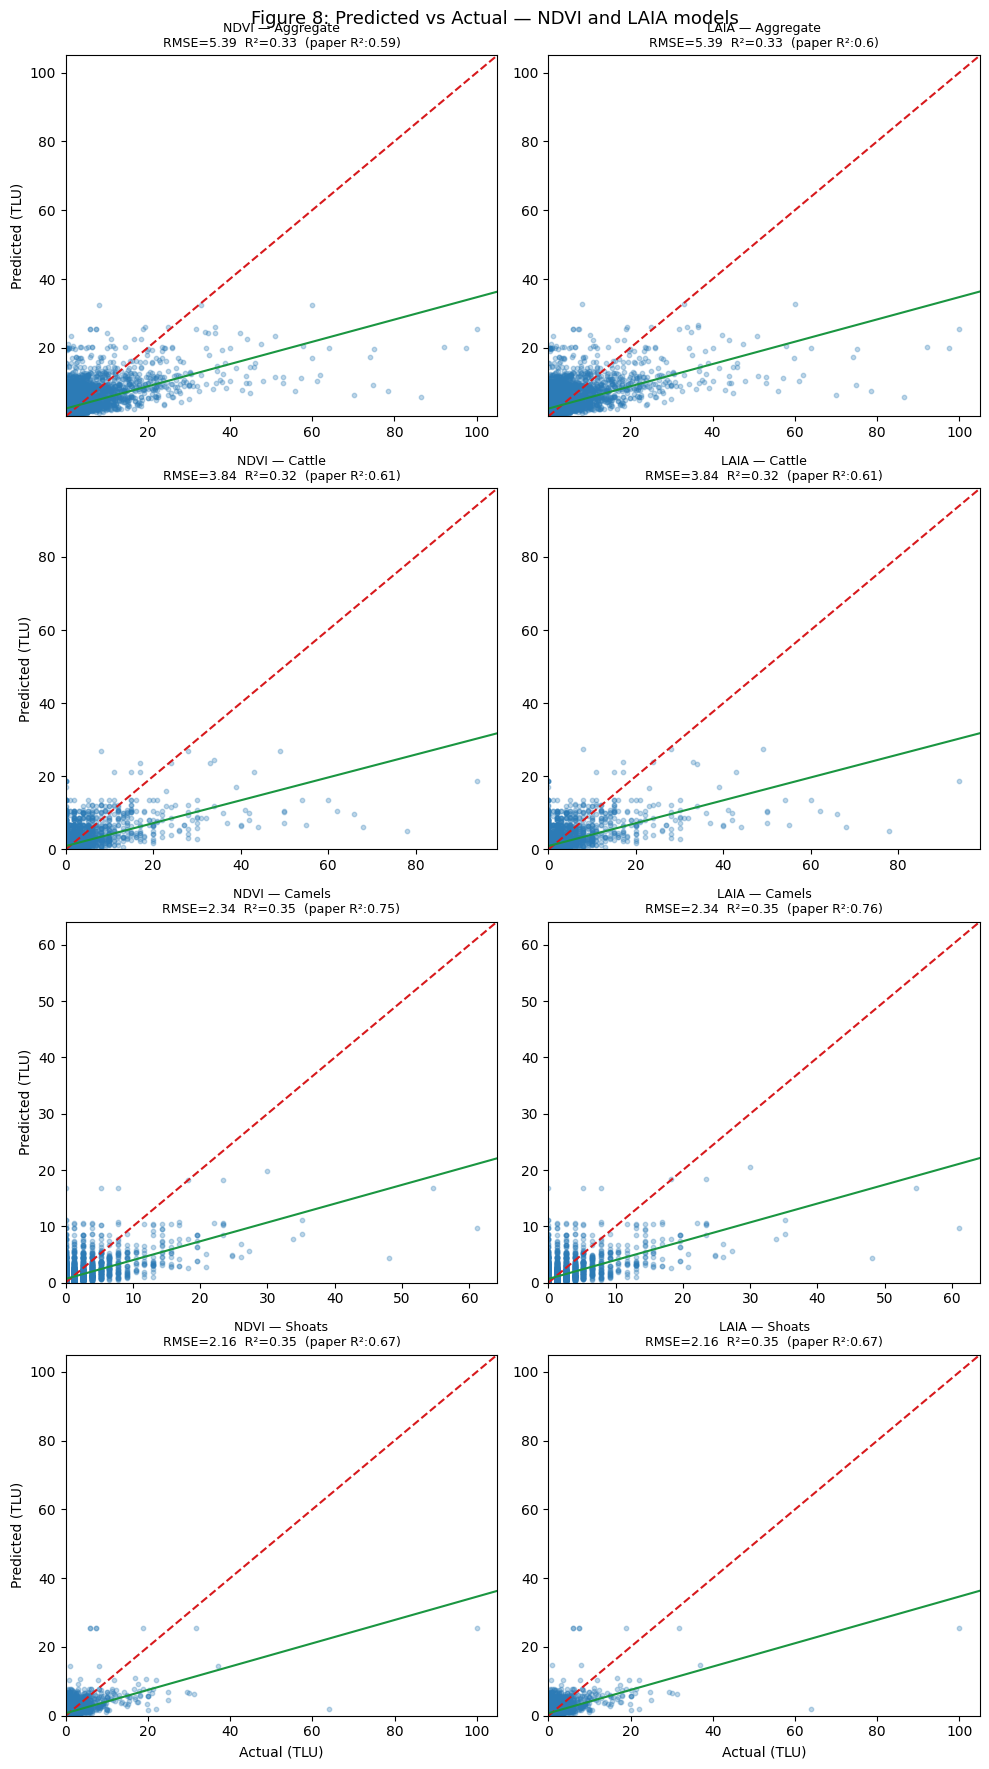

In [19]:
sp_labels = {'aggregate':'Aggregate','cattle':'Cattle','camel':'Camels','shoat':'Shoats'}
fig, axes = plt.subplots(4, 2, figsize=(10, 18))

for ri, sp in enumerate(['aggregate','cattle','camel','shoat']):
    for ci, mn in enumerate(['NDVI','LAIA']):
        ax = axes[ri][ci]
        if mn not in ALL_RESULTS or sp not in ALL_RESULTS[mn]:
            ax.axis('off'); continue
        res  = ALL_RESULTS[mn][sp]
        act  = res['actual']; pred = res['predicted']
        lim  = [min(act.min(),pred.min())*0.95, max(act.max(),pred.max())*1.05]
        ax.scatter(act, pred, alpha=0.3, s=10, color='#2c7bb6')
        ax.plot(lim, lim, '--', color='#d7191c', lw=1.5)
        sl, ic, *_ = scipy_stats.linregress(act, pred)
        x_line = np.linspace(*lim, 50)
        ax.plot(x_line, sl*x_line+ic, '-', color='#1a9641', lw=1.5)
        p = PAPER.get((mn,sp), (None,None))
        ax.set_title(
            f'{mn} — {sp_labels[sp]}\nRMSE={res["rmse"]:.2f}  R²={res["r2"]:.2f}'
            + (f'  (paper R²:{p[1]})' if p[1] else ''), fontsize=9)
        ax.set_xlim(lim); ax.set_ylim(lim)
        if ci == 0: ax.set_ylabel('Predicted (TLU)')
        if ri == 3: ax.set_xlabel('Actual (TLU)')

plt.suptitle('Figure 8: Predicted vs Actual — NDVI and LAIA models', fontsize=13)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}03_fig8_scatter.png', dpi=150, bbox_inches='tight')
plt.show()


---
## CELL 16 — Figure 9: Variable Importance


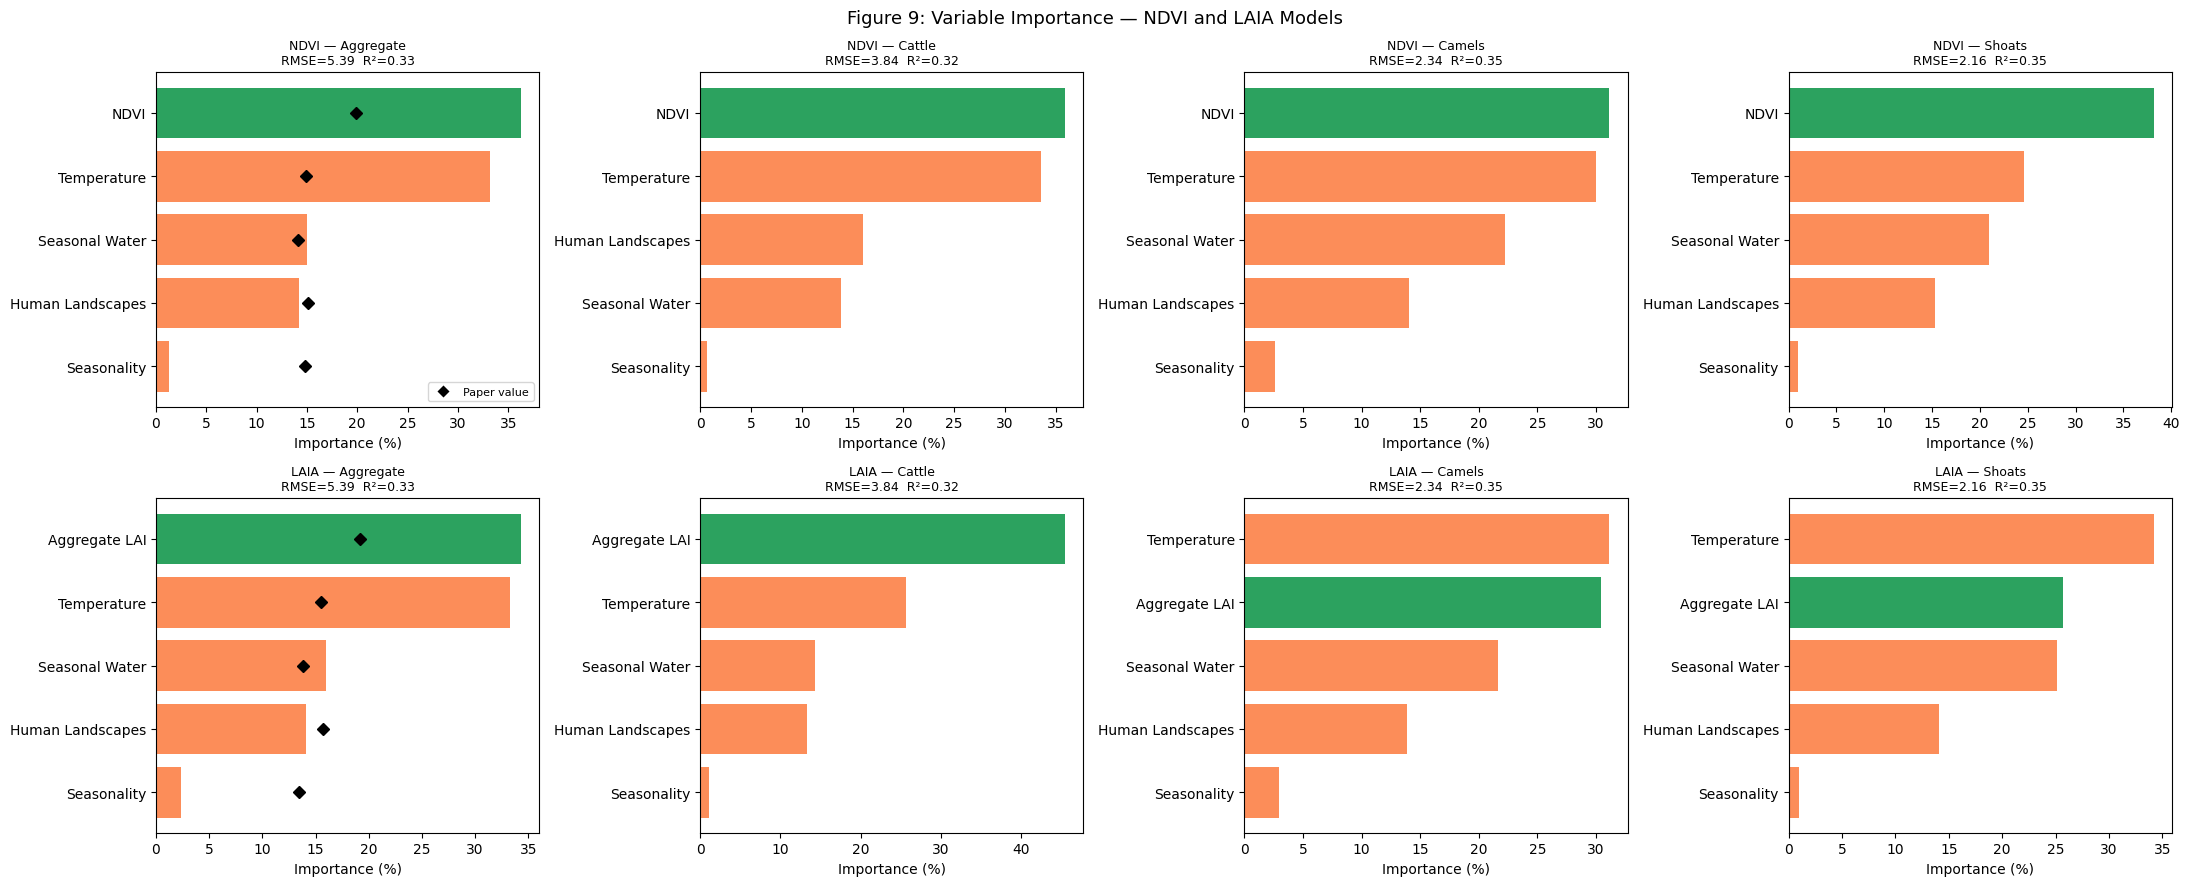

REPLICATION SUMMARY — Kahiu et al. 2024 (NDVI vs LAIA)

── NDVI ──
  aggregate   RMSE=5.39(±0.00)(paper:9.33) ← Δ=3.94  R²=0.334(paper:0.59)
  cattle      RMSE=3.84(±0.00)(paper:13.41) ← Δ=9.57  R²=0.322(paper:0.61)
  camel       RMSE=2.34(±0.00)(paper:6.08) ← Δ=3.74  R²=0.350(paper:0.75)
  shoat       RMSE=2.16(±0.00)(paper:2.37) ✓  R²=0.348(paper:0.67)

── LAIA ──
  aggregate   RMSE=5.39(±0.00)(paper:9.3) ← Δ=3.91  R²=0.334(paper:0.6)
  cattle      RMSE=3.84(±0.00)(paper:13.38) ← Δ=9.54  R²=0.322(paper:0.61)
  camel       RMSE=2.34(±0.00)(paper:6.03) ← Δ=3.69  R²=0.350(paper:0.76)
  shoat       RMSE=2.16(±0.00)(paper:2.37) ✓  R²=0.348(paper:0.67)

── NDVI vs LAIA R² (paper: both ~0.60 aggregate) ──
  aggregate : NDVI=0.334  LAIA=0.334
  cattle    : NDVI=0.322  LAIA=0.322
  camel     : NDVI=0.350  LAIA=0.350
  shoat     : NDVI=0.348  LAIA=0.348

── Output files ──
  01_buffers.png  (191 KB)
  02_fig7_forage_timeseries.png  (151 KB)
  02_fig7_lai_timeseries.png  (84 KB)
  02b_fig7_ndvi

In [20]:
VAR_LABELS = {
    'zNDVI':         'NDVI',
    'zLAIA':         'Aggregate LAI',
    'zTemp':         'Temperature',
    'human_density': 'Human Landscapes',
    'water_density': 'Seasonal Water',
    'season_bin':    'Seasonality',
}
# Paper variable importance for NDVI and LAIA aggregate models (Table 4)
PAPER_IMP = {
    'NDVI': {
        'aggregate': {'NDVI':19.9,'Human Landscapes':15.1,'Temperature':14.9,
                      'Seasonality':14.8,'Seasonal Water':14.1},
    },
    'LAIA': {
        'aggregate': {'Aggregate LAI':19.2,'Human Landscapes':15.7,'Temperature':15.5,
                      'Seasonal Water':13.8,'Seasonality':13.4},
    },
}

fig, axes = plt.subplots(2, 4, figsize=(22, 9))
for mi, mname in enumerate(['NDVI','LAIA']):
    if mname not in ALL_RESULTS: continue
    for ai, (sp, title) in enumerate([
        ('aggregate','Aggregate'),('cattle','Cattle'),('camel','Camels'),('shoat','Shoats')
    ]):
        ax = axes[mi][ai]
        if sp not in ALL_RESULTS[mname]: ax.axis('off'); continue
        imp    = ALL_RESULTS[mname][sp]['importance']
        df_imp = pd.Series(imp).rename(index=VAR_LABELS).sort_values(ascending=True)
        colors = ['#2ca25f' if v in ('NDVI','Aggregate LAI') else '#fc8d59'
                  for v in df_imp.index]
        ax.barh(df_imp.index, df_imp.values, color=colors)
        # Paper values as diamond markers
        for var_label, pval in PAPER_IMP.get(mname,{}).get(sp,{}).items():
            if var_label in df_imp.index:
                ax.plot(pval, list(df_imp.index).index(var_label),
                        'D', color='black', markersize=6)
        res = ALL_RESULTS[mname][sp]
        ax.set_title(f'{mname} — {title}\nRMSE={res["rmse"]:.2f}  R²={res["r2"]:.2f}',
                     fontsize=9)
        ax.set_xlabel('Importance (%)')

axes[0][0].legend(handles=[
    Line2D([0],[0],marker='D',color='w',markerfacecolor='black',markersize=7,
           label='Paper value')
], fontsize=8)
plt.suptitle('Figure 9: Variable Importance — NDVI and LAIA Models', fontsize=13)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}04_fig9_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Final summary ─────────────────────────────────────────────────────
print('='*70)
print('REPLICATION SUMMARY — Kahiu et al. 2024 (NDVI vs LAIA)')
print('='*70)
for mname in ['NDVI','LAIA']:
    if mname not in ALL_RESULTS: continue
    print(f'\n── {mname} ──')
    for tname in ['aggregate','cattle','camel','shoat']:
        if tname not in ALL_RESULTS[mname]: continue
        res  = ALL_RESULTS[mname][tname]
        p    = PAPER.get((mname,tname), (None,None))
        diff = abs(res['rmse']-p[0]) if p[0] else None
        flag = ' ✓' if diff and diff<1.0 else f' ← Δ={diff:.2f}' if diff else ''
        print(f"  {tname:10s}  RMSE={res['rmse']:.2f}(±{res['rmse_std']:.2f})"
              f"(paper:{p[0]}){flag}  R²={res['r2']:.3f}(paper:{p[1]})")

print('\n── NDVI vs LAIA R² (paper: both ~0.60 aggregate) ──')
for tname in ['aggregate','cattle','camel','shoat']:
    r1 = ALL_RESULTS.get('NDVI',{}).get(tname,{}).get('r2')
    r2 = ALL_RESULTS.get('LAIA',{}).get(tname,{}).get('r2')
    if r1 and r2:
        print(f'  {tname:10s}: NDVI={r1:.3f}  LAIA={r2:.3f}')

print('\n── Output files ──')
for fname in sorted(os.listdir(OUT_DIR)):
    size = os.path.getsize(os.path.join(OUT_DIR,fname))/1024
    print(f'  {fname}  ({size:.0f} KB)')


---
## CELL 17 — Leave-one-year-out cross-validation

The paper reports **in-sample** R² — random forests memorise training data so
in-sample metrics are inflated by overfitting.

**Leave-one-year-out (LOYO) CV** holds out one survey year at a time
(2009, 2010, 2011, 2012, 2013, 2015, 2021), trains on the other six, and
predicts the held-out year. This gives an honest out-of-sample R² and RMSE.

Memory note: folds run **sequentially**, forests built with **`n_jobs=1`**,
and only **10 seeds** are used (sufficient for stable OOS estimates; the point
is the held-out metric, not seed-to-seed variance).


In [21]:
def run_loyo_cv(df, features, target_col, n_seeds=10, year_col='survey_year'):
    """
    Leave-one-year-out cross-validation.
    Folds run sequentially; forests are single-threaded to cap memory.
    """
    sub   = df[features + [target_col, year_col]].dropna()
    years = sorted(sub[year_col].unique())

    fold_rows              = []
    all_actual, all_pred   = [], []

    for hold_yr in years:
        train = sub[sub[year_col] != hold_yr]
        test  = sub[sub[year_col] == hold_yr]
        if len(train) < 10 or len(test) == 0:
            continue

        X_tr, y_tr = train[features].values, train[target_col].values
        X_te, y_te = test[features].values,  test[target_col].values

        # Average n_seeds forests — sequential, n_jobs=1 to bound memory
        seed_preds = []
        for seed in range(1, n_seeds + 1):
            rf = RandomForestRegressor(
                n_estimators=500, random_state=seed, n_jobs=1
            )
            rf.fit(X_tr, y_tr)
            seed_preds.append(rf.predict(X_te))
            del rf          # free immediately

        preds      = np.vstack(seed_preds).mean(axis=0)
        rmse_fold  = np.sqrt(mean_squared_error(y_te, preds))
        ss_tot     = np.sum((y_te - y_te.mean()) ** 2)
        r2_fold    = 1 - np.sum((y_te - preds) ** 2) / ss_tot if ss_tot > 0 else np.nan

        fold_rows.append({
            'held_out_year': hold_yr,
            'n_test':        len(y_te),
            'n_train':       len(y_tr),
            'rmse':          rmse_fold,
            'r2':            r2_fold,
        })
        all_actual.extend(y_te.tolist())
        all_pred.extend(preds.tolist())
        print(f'    {hold_yr}: n_test={len(y_te)}  RMSE={rmse_fold:.2f}  R²={r2_fold:.3f}',
              flush=True)

    all_actual   = np.array(all_actual)
    all_pred     = np.array(all_pred)
    overall_rmse = np.sqrt(mean_squared_error(all_actual, all_pred))
    ss_tot       = np.sum((all_actual - all_actual.mean()) ** 2)
    overall_r2   = 1 - np.sum((all_actual - all_pred) ** 2) / ss_tot

    return {
        'folds':        fold_rows,
        'actual':       all_actual,
        'predicted':    all_pred,
        'overall_rmse': overall_rmse,
        'overall_r2':   overall_r2,
    }


LOYO_RESULTS = {}
for mname, feats in MODELS.items():
    if not all(f in model_data.columns for f in feats):
        print(f'Skipping {mname} — missing features'); continue
    LOYO_RESULTS[mname] = {}
    print(f'\nModel: {mname}', flush=True)
    for tname, tcol in TARGETS.items():
        print(f'  {tname}:', flush=True)
        res = run_loyo_cv(model_data, feats, tcol)
        LOYO_RESULTS[mname][tname] = res
        print(f'  → overall  RMSE={res["overall_rmse"]:.2f}  R²={res["overall_r2"]:.3f}',
              flush=True)

print('\n✓ LOYO CV complete.')



Model: NDVI
  aggregate:
    2009: n_test=1168  RMSE=9.78  R²=-0.160
    2010: n_test=806  RMSE=6.27  R²=-0.053
    2011: n_test=1052  RMSE=9.29  R²=-0.080
    2012: n_test=845  RMSE=4.82  R²=-0.226
    2013: n_test=869  RMSE=2.39  R²=-0.964
    2015: n_test=904  RMSE=6.24  R²=-4.921
    2021: n_test=270  RMSE=3.01  R²=-0.185
  → overall  RMSE=7.08  R²=-0.149
  cattle:
    2009: n_test=1168  RMSE=7.73  R²=-0.088
    2010: n_test=806  RMSE=4.74  R²=-0.018
    2011: n_test=1052  RMSE=5.82  R²=-0.017
    2012: n_test=845  RMSE=2.78  R²=-2.324
    2013: n_test=869  RMSE=1.12  R²=-1.009
    2015: n_test=904  RMSE=4.28  R²=-6.362
    2021: n_test=270  RMSE=1.63  R²=-2.225
  → overall  RMSE=5.01  R²=-0.150
  camel:
    2009: n_test=1168  RMSE=2.71  R²=0.006
    2010: n_test=806  RMSE=3.16  R²=-0.016
    2011: n_test=1052  RMSE=4.42  R²=-0.026
    2012: n_test=845  RMSE=2.94  R²=0.020
    2013: n_test=869  RMSE=1.45  R²=-0.114
    2015: n_test=904  RMSE=1.68  R²=-0.181
    2021: n_test=270  R

---
## CELL 18 — LOYO results: in-sample vs out-of-sample


In [22]:
print('=' * 80)
print('IN-SAMPLE vs LEAVE-ONE-YEAR-OUT CV')
print('=' * 80)
print(f'  {"Model / Target":30s} {"IS RMSE":>8s} {"IS R²":>7s}   '
      f'{"OOS RMSE":>9s} {"OOS R²":>8s}   {"Paper RMSE":>11s} {"Paper R²":>9s}')
print('-' * 80)

loyo_rows = []
for mname in ['NDVI', 'LAIA']:
    for tname in ['aggregate', 'cattle', 'camel', 'shoat']:
        ins   = ALL_RESULTS.get(mname, {}).get(tname)
        oos   = LOYO_RESULTS.get(mname, {}).get(tname)
        paper = PAPER.get((mname, tname), (None, None))
        if not ins or not oos:
            continue
        label = f'{mname} / {tname}'
        print(f'  {label:30s} {ins["rmse"]:8.2f} {ins["r2"]:7.3f}   '
              f'{oos["overall_rmse"]:9.2f} {oos["overall_r2"]:8.3f}   '
              f'{str(paper[0]):>11s} {str(paper[1]):>9s}')
        loyo_rows.append({
            'Model': mname, 'Target': tname,
            'IS_RMSE':   round(ins['rmse'], 2),
            'IS_R2':     round(ins['r2'], 3),
            'OOS_RMSE':  round(oos['overall_rmse'], 2),
            'OOS_R2':    round(oos['overall_r2'], 3),
            'Paper_RMSE': paper[0],
            'Paper_R2':   paper[1],
        })

print('=' * 80)
pd.DataFrame(loyo_rows).to_csv(f'{OUT_DIR}loyo_cv_results.csv', index=False)
print('Saved → outputs/loyo_cv_results.csv')

# Per-fold breakdown for LAIA aggregate
print('\n── Per-fold: LAIA aggregate ──')
if 'LAIA' in LOYO_RESULTS and 'aggregate' in LOYO_RESULTS['LAIA']:
    print(f'  {"Year":>6s} {"N test":>8s} {"RMSE":>8s} {"R²":>8s}')
    for f in LOYO_RESULTS['LAIA']['aggregate']['folds']:
        print(f'  {f["held_out_year"]:>6d} {f["n_test"]:>8d} '
              f'{f["rmse"]:>8.2f} {f["r2"]:>8.3f}')

print('\n── R² drop: in-sample → out-of-sample ──')
for mname in ['NDVI', 'LAIA']:
    for sp in ['aggregate', 'cattle', 'camel', 'shoat']:
        ins_r2 = ALL_RESULTS.get(mname, {}).get(sp, {}).get('r2')
        oos_r2 = LOYO_RESULTS.get(mname, {}).get(sp, {}).get('overall_r2')
        if ins_r2 is None or oos_r2 is None: continue
        print(f'  {mname}/{sp:10s}  IS={ins_r2:.3f}  OOS={oos_r2:.3f}  '
              f'drop={ins_r2-oos_r2:+.3f}')


IN-SAMPLE vs LEAVE-ONE-YEAR-OUT CV
  Model / Target                  IS RMSE   IS R²    OOS RMSE   OOS R²    Paper RMSE  Paper R²
--------------------------------------------------------------------------------
  NDVI / aggregate                   5.39   0.334        7.08   -0.149          9.33      0.59
  NDVI / cattle                      3.84   0.322        5.01   -0.150         13.41      0.61
  NDVI / camel                       2.34   0.350        2.90   -0.002          6.08      0.75
  NDVI / shoat                       2.16   0.348        2.84   -0.126          2.37      0.67
  LAIA / aggregate                   5.39   0.334        6.83   -0.070           9.3       0.6
  LAIA / cattle                      3.84   0.322        4.72   -0.020         13.38      0.61
  LAIA / camel                       2.34   0.350        2.92   -0.015          6.03      0.76
  LAIA / shoat                       2.16   0.348        2.94   -0.207          2.37      0.67
Saved → outputs/loyo_cv_resul

---
## CELL 19 — Predicted vs actual: out-of-sample (LOYO)


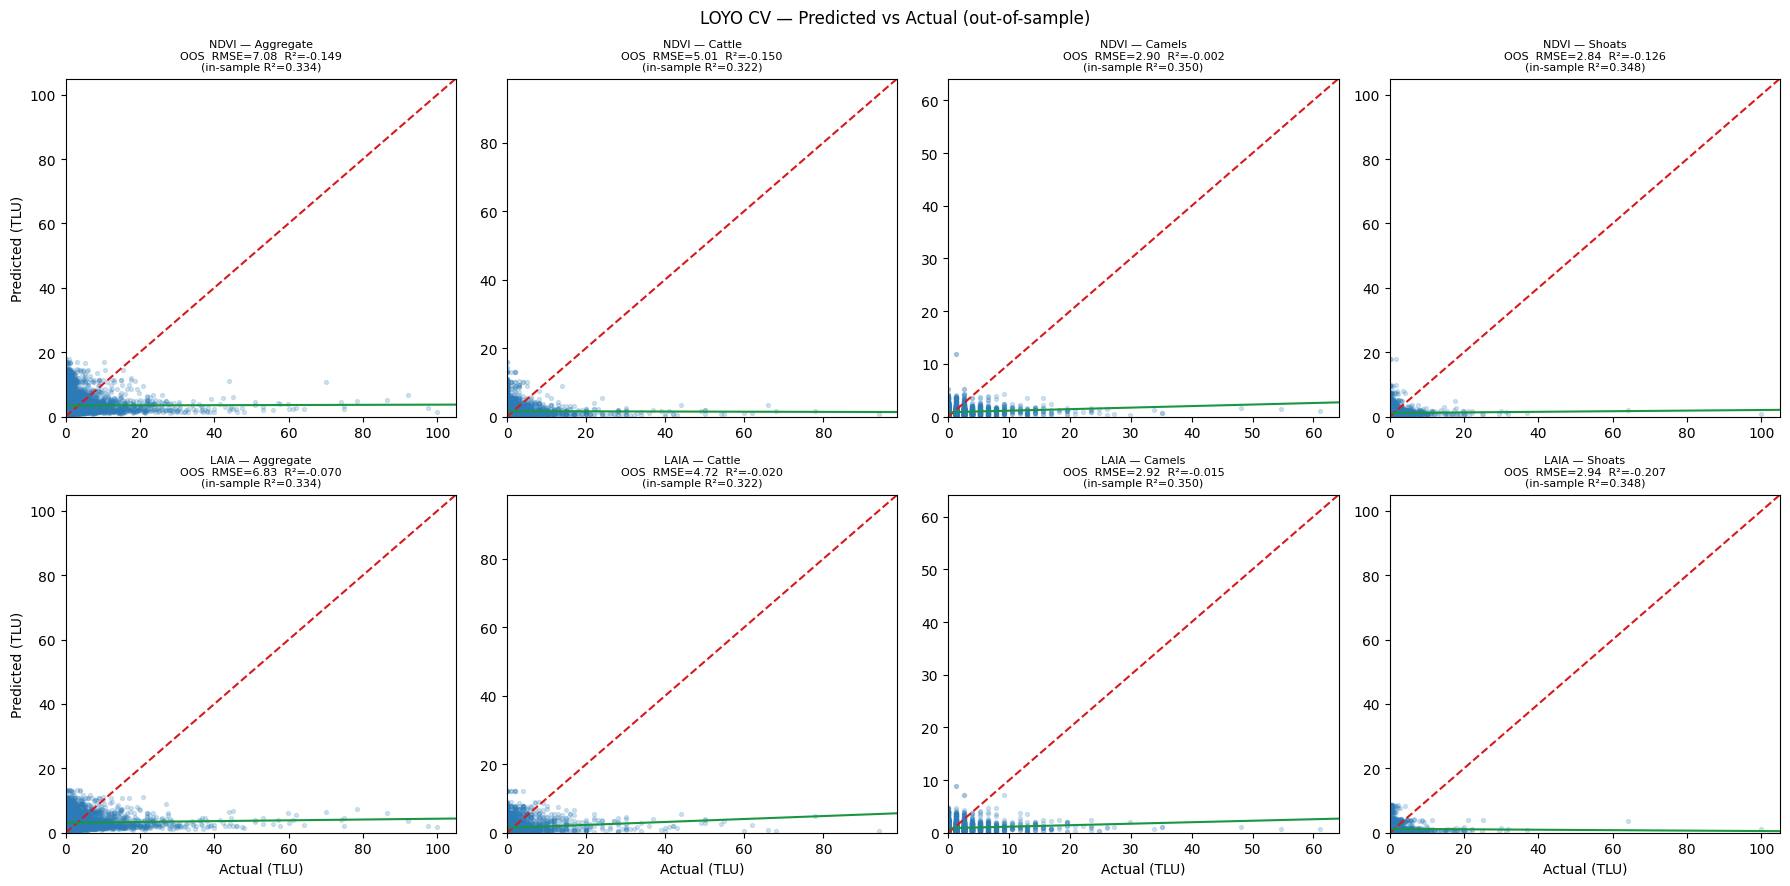

Saved → outputs/05_loyo_scatter.png


In [23]:
sp_labels = {'aggregate':'Aggregate','cattle':'Cattle','camel':'Camels','shoat':'Shoats'}
fig, axes = plt.subplots(2, 4, figsize=(18, 9))

for mi, mname in enumerate(['NDVI','LAIA']):
    for ai, sp in enumerate(['aggregate','cattle','camel','shoat']):
        ax  = axes[mi][ai]
        res = LOYO_RESULTS.get(mname, {}).get(sp)
        ins = ALL_RESULTS.get(mname, {}).get(sp)
        if res is None: ax.axis('off'); continue

        act  = res['actual']
        pred = res['predicted']
        lim  = [0, max(act.max(), pred.max()) * 1.05]

        ax.scatter(act, pred, alpha=0.2, s=8, color='#2c7bb6')
        ax.plot(lim, lim, '--', color='#d7191c', lw=1.5)
        sl, ic, *_ = scipy_stats.linregress(act, pred)
        x_line = np.linspace(*lim, 50)
        ax.plot(x_line, sl*x_line+ic, '-', color='#1a9641', lw=1.5)
        ax.set_xlim(lim); ax.set_ylim(lim)
        ax.set_title(
            f'{mname} — {sp_labels[sp]}\n'
            f'OOS  RMSE={res["overall_rmse"]:.2f}  R²={res["overall_r2"]:.3f}\n'
            f'(in-sample R²={ins["r2"]:.3f})',
            fontsize=8,
        )
        if ai == 0: ax.set_ylabel('Predicted (TLU)')
        if mi == 1: ax.set_xlabel('Actual (TLU)')

plt.suptitle('LOYO CV — Predicted vs Actual (out-of-sample)', fontsize=12)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}05_loyo_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → outputs/05_loyo_scatter.png')
